In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

from lite_org import LITE
from utils import load_data, preprocess_data
import os
from  utils import *

import warnings
warnings.filterwarnings('ignore')

In [21]:
def evaluate_ensemble_base(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float())[0] for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            # Apply softmax to convert logits to probabilities
   
            avg_probs = sum(probs) / len(probs)

            # Get the predicted class
            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    print('')
    accuracy = accuracy_score(all_targets, all_preds)
    print(f'Ensemble Accuracy: {accuracy:.4f}')
    return accuracy

def evaluate_ensemble_pruned(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model.forward_sparsity(data.float())[0] for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            # Apply softmax to convert logits to probabilities
   
            avg_probs = sum(probs) / len(probs)

            # Get the predicted class
            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    print(f'Ensemble Accuracy: {accuracy:.4f}')
    return accuracy

def copy_params(base_model, pruned_model, conv_group_1, conv_group_2, conv_group_3, all_indicies, indicies_2, indicies_3,  out_dir):
    print('conv_group_1 size: ', conv_group_1.shape)
    print('conv_group_2 size: ', conv_group_2.shape)
    print('conv_group_3 size: ', conv_group_3.shape)
    print('conv_group_1 : ', conv_group_1)
    print('conv_group_2 : ', conv_group_2)
    print('conv_group_3 : ', conv_group_3)

    
    model_base_state_dict = base_model.state_dict()
    model_pruned_state_dict = pruned_model.state_dict()

    for name, param in model_base_state_dict.items():
        print()
        if 'num_batches_tracked' in name:
            continue
        
        elif 'inception.inception_layers.0.weight' in name:            
            model_pruned_state_dict[name] = param[conv_group_1].clone()
            # print(' 111 **************************************\n\n')
            
        elif 'inception.inception_layers.1.weight' in name:            
            model_pruned_state_dict[name] = param[conv_group_2].clone()
            # print(' 222 **************************************\n\n')
            
        elif 'inception.inception_layers.2.weight' in name:
            model_pruned_state_dict[name] = param[conv_group_3].clone()
            # print(' 333 **************************************\n\n')

        elif 'inception.hybrid.hybrid_block' in name:
            model_pruned_state_dict[name] = param.clone()
            # print(' 444 **************************************\n\n')

        elif 'inception.bn' in name:
            model_pruned_state_dict[name] = param[all_indicies].clone()
            # print(' 555 **************************************')
            
        elif 'fcn_module1.depthwise_conv' in name:
            model_pruned_state_dict[name] = param[all_indicies].clone()
            # print(' 666 **************************************')

        elif 'fcn_module1.pointwise_conv' in name:
            rows, cols = torch.meshgrid(indicies_2, all_indicies, indexing="ij")
            model_pruned_state_dict[name] = param[rows, cols, :].clone()
            # print(' 777 **************************************')
            
        elif 'fcn_module1.bn' in name:
            model_pruned_state_dict[name] = param[indicies_2].clone()
            # print(' 888 **************************************')
            
        elif 'fcn_module2.depthwise_conv' in name:
            model_pruned_state_dict[name] = param[indicies_2].clone()
            # print(' 999 **************************************')

        elif 'fcn_module2.pointwise_conv' in name:
            rows, cols = torch.meshgrid(indicies_3, indicies_2, indexing="ij")
            model_pruned_state_dict[name] = param[rows, cols, :].clone()
            # print(' 10_10 **************************************')

        elif 'fcn_module2.bn' in name:
            model_pruned_state_dict[name] = param[indicies_3].clone()
            # print(' 11_11 **************************************')

        elif 'fc1.weight' in name:
            model_pruned_state_dict[name] = param[:, indicies_3].clone()
            # print(' 12_12 **************************************')

        elif 'fc1.bias' in name:
            model_pruned_state_dict[name] = param.clone()
            # print(' 13_13 **************************************')
        
        else:
            print('AAAAAAAAAAAAAAAAAAAAA')
        #     print('Yes')
    
    print('\n\n')
    # pruned_model.load_state_dict(model_pruned_state_dict)    
    # torch.save(pruned_model, out_dir + 'pruned_model_1e-7_w_4_2_1.pth')
    return pruned_model

def test(model, dataloader):
    
    model.eval()
    correct, total = 0, 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        
        inputs, targets = inputs.cuda(), targets.cuda()

        outputs, features = model.forward_sparsity(inputs.float())
        
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += predicted.eq(targets.data).cpu().sum().float().item()

    # print('Accuracy: ', 100. * correct / total)
    return 100. * correct / total

In [ ]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]

ds_names = ['Ham']
seeds = [9409, 3804, 3952, 2561, 5296]
# seeds = [2561]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens', 'base_params', 'co_params', 'fil_l_1_1', 'fil_l_1_2', 'fil_l_1_3', 'fil_l_2', 'fil_l_3']
res_df_2 = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    print('Dataset: ', dataset)
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))
    models_base, models_base_norm, models_pruned = [], [], []
    num_params_pruned, num_params_base = 0, 0
    filters_layer_1_1, filters_layer_1_2, filters_layer_1_3, filters_layer_2, filters_layer_3 = 0, 0, 0, 0, 0
    
    
    for seed in seeds:
        print('seed: ', seed)
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        num_params_base += sum(p.numel() for p in model_base.parameters())
        
        model_base_norm = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        # model_base_norm.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_base_norm.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        
        model_base_norm.cuda()
        model_base_norm.eval()
        models_base_norm.append(model_base_norm)
        # rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_1e-6_no_weights/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        # num_params_base += sum(p.numel() for p in model_base_norm.parameters())
        
        all_mask_1, all_mask_2, all_mask_3 = [], [], []
        with torch.no_grad():
            for b_idx, (data, target) in enumerate(trainloader):
                data, target = data.cuda(), target.cuda()
                outputs, features, prune_ratios, masks, depth_outs  = model_base_norm.forward_sparsity_2(data.float())
                all_mask_1.append(masks[0])
                all_mask_2.append(masks[1])
                all_mask_3.append(masks[2])
                
        all_mask_1 = torch.cat(all_mask_1, dim=0)
        all_mask_2 = torch.cat(all_mask_2, dim=0)
        all_mask_3 = torch.cat(all_mask_3, dim=0)
        print('all_mask_1 shape: ', all_mask_1.shape)
        
        mask_1_org = all_mask_1.squeeze(-1)
        mask_1 = mask_1_org[:, :96]
        mask_2 = all_mask_2.squeeze(-1)
        mask_3 = all_mask_3.squeeze(-1)

        # Third layer
        tmp_3 = mask_3.sum(dim=0) # (num of filters)
        indicies_3, conv_3_size  = torch.where(tmp_3 > 1)[0], torch.where(tmp_3 > 1)[0].shape[0]
        if conv_3_size == 0:
            indicies_3 = torch.tensor([0], device=indicies_3.device)
            conv_3_size = 1
        
        print(f'Third layer: {indicies_3}')
        print(f'Second layer conv size: {conv_3_size}')
        
        # Second layer
        tmp_2 = mask_2.sum(dim=0)
        indicies_2, conv_2_size  = torch.where(tmp_2 > 1)[0], torch.where(tmp_2 > 1)[0].shape[0]
        if conv_2_size == 0:
            indicies_2 = torch.tensor([0], device=indicies_2.device)
            conv_2_size = 1
        print(f'Second layer: {indicies_2}')
        print(f'Second layer conv size: {conv_2_size}')
        

        # First layer
        tmp_1 = mask_1.sum(dim=0)
        indices = torch.where(tmp_1 > 1)[0]
        
        conv_group_1, conv_group_1_size = indices[indices < 32], indices[indices < 32].shape[0]
        conv_group_2, conv_group_2_size = indices[(indices >= 32) & (indices < 64)], indices[(indices >= 32) & (indices < 64)].shape[0]
        conv_group_3, conv_group_3_size = indices[(indices >= 64) & (indices < 96)], indices[(indices >= 64) & (indices < 96)].shape[0]
        # print('conv_group_1: ', conv_group_1)
            
        conv_group_2 = conv_group_2 - 32
        conv_group_3 = conv_group_3 - 64
        
        tmp = mask_1_org.sum(dim=0)
        print('mask_1_org shape: ', mask_1_org.shape)
        all_indicies = torch.where(tmp > 1)[0]
        all_indicies
        print('all indices after: ', all_indicies)
        
        if conv_group_1_size == 0:
            conv_group_1 = torch.tensor([0], device=indices.device)
            conv_group_1_size = 1
            all_indicies = torch.cat((all_indicies, torch.tensor([0], device=all_indicies.device)))
        if conv_group_2_size == 0:
            conv_group_2 = torch.tensor([0], device=indices.device)
            conv_group_2_size = 1            
            all_indicies = torch.cat((all_indicies, torch.tensor([32], device=all_indicies.device)))          
        if conv_group_3_size == 0:
            conv_group_3 = torch.tensor([0], device=indices.device)
            conv_group_3_size = 1
            print('all indices before: ', all_indicies)            
            all_indicies = torch.cat((all_indicies, torch.tensor([64], device=all_indicies.device)))
            print('all indices after: ', all_indicies)
        
            print('aaaa')
            

        print('conv_group_1 size: ', conv_group_1.shape)
        model_pruned = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, 
                    n_filters=[[conv_group_1_size, conv_group_2_size, conv_group_3_size], conv_2_size, conv_3_size])
        model_pruned.cuda()

        filters_layer_1_1 += conv_group_1_size
        filters_layer_1_2 += conv_group_2_size 
        filters_layer_1_3 += conv_group_3_size
        
        filters_layer_2 += conv_2_size
        filters_layer_3 += conv_3_size
        
        
        
        num_params_pruned += sum(p.numel() for p in model_pruned.parameters())
        print('Number of parameters from the pruned model: ', sum(p.numel() for p in model_pruned.parameters()) )
        
        out_dir = os.getcwd() + f'/results/'       
        # out_dir = os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/'       
        
        print('Copying parameters started')         
        model_pruned = copy_params(model_base_norm, model_pruned, conv_group_1, conv_group_2, conv_group_3, all_indicies, indicies_2, indicies_3, out_dir )
        print('Copying parameters ended')         
        
        # model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
        models_pruned.append(model_pruned)
        rows.append(test(model_pruned, testloader))
        print('\n\n')
        
                
    
    num_params_pruned /= 5
    num_params_base /= 5
    base_acc = evaluate_ensemble_base(models_base, testloader)
    print('Base accuracy: ', base_acc)
    rows.append(base_acc)
    
    pruned_acc = evaluate_ensemble_base(models_pruned, testloader)
    print('Pruned model accuracy: ', pruned_acc)
    rows.append(pruned_acc)
    
    rows.append(num_params_base)
    rows.append(num_params_pruned)    
    
    
    filters_layer_1_1 /= 5
    filters_layer_1_2 /= 5
    filters_layer_1_3 /= 5
    filters_layer_2 /= 5
    filters_layer_3 /= 5

    rows.append(filters_layer_1_1)
    rows.append(filters_layer_1_2)
    rows.append(filters_layer_1_3)
    rows.append(filters_layer_2)
    rows.append(filters_layer_3)
    
    
    res_df_2 = pd.concat([res_df_2, pd.DataFrame([rows], columns=columns)])    
    # break

In [29]:
res_df_2['prune_ratio'] = 1 - (res_df_2['co_params'] / res_df_2['base_params'])

In [30]:
res_df_2['prune_ratio'].mean()

np.float64(0.38150141328769793)

In [ ]:
model_pruned.fcn_module1.depthwise_conv.weight.data

In [124]:
tmp_mask = tmp_mask.reshape(7200, 113)

In [125]:
tmp_mask.shape

torch.Size([7200, 113])

In [127]:
tmp_mask = tmp_mask[:, :96]

In [129]:
torch.sum(tmp_mask, dim=0)

tensor([1090, 1958, 3097, 1514, 3021, 1576, 2151, 1243, 1769, 1325, 2870, 1905,
        2213, 2251, 2253, 1534, 2022, 1708, 1010, 3377, 2254, 2908, 1631,  898,
        1179, 2095, 1611, 1140, 2435, 2327, 2500,  451,  810, 2625,  430, 1060,
        1224,  274, 1935, 2251, 2945, 2063, 2038, 2330, 1041, 2280, 2508, 1687,
        2238, 2420, 2013,  535,  395,  689,  295, 2833, 1424, 2469,  591, 2189,
        2649, 1982, 2285, 2424, 2474, 1003,  976, 1939, 1823,  854, 2178,  841,
        3212,   73, 2798,  363, 2239, 2306, 2447, 1984,  924, 1259, 1983,  314,
        1018, 1885, 1262, 1143, 1539,  517, 2026,  362, 2441,  622,  520, 1636],
       device='cuda:0')

In [115]:
torch.sum(tmp_mask, dim=0)

tensor([1571, 2315, 3129, 2134, 1246,  494, 3045, 1811, 1545, 1545, 2015, 1307,
        2501, 2235, 2536, 1815, 2342, 2288, 2141, 1556, 1715, 1092, 1647, 1688,
        2221, 1892, 1640, 2758, 2281, 2062, 1883,  562], device='cuda:0')

In [116]:
1086/7200

0.15083333333333335

In [118]:
7200/24

300.0

In [23]:
mask_3.shape

torch.Size([109, 32])

feat map shape:  torch.Size([109, 32])


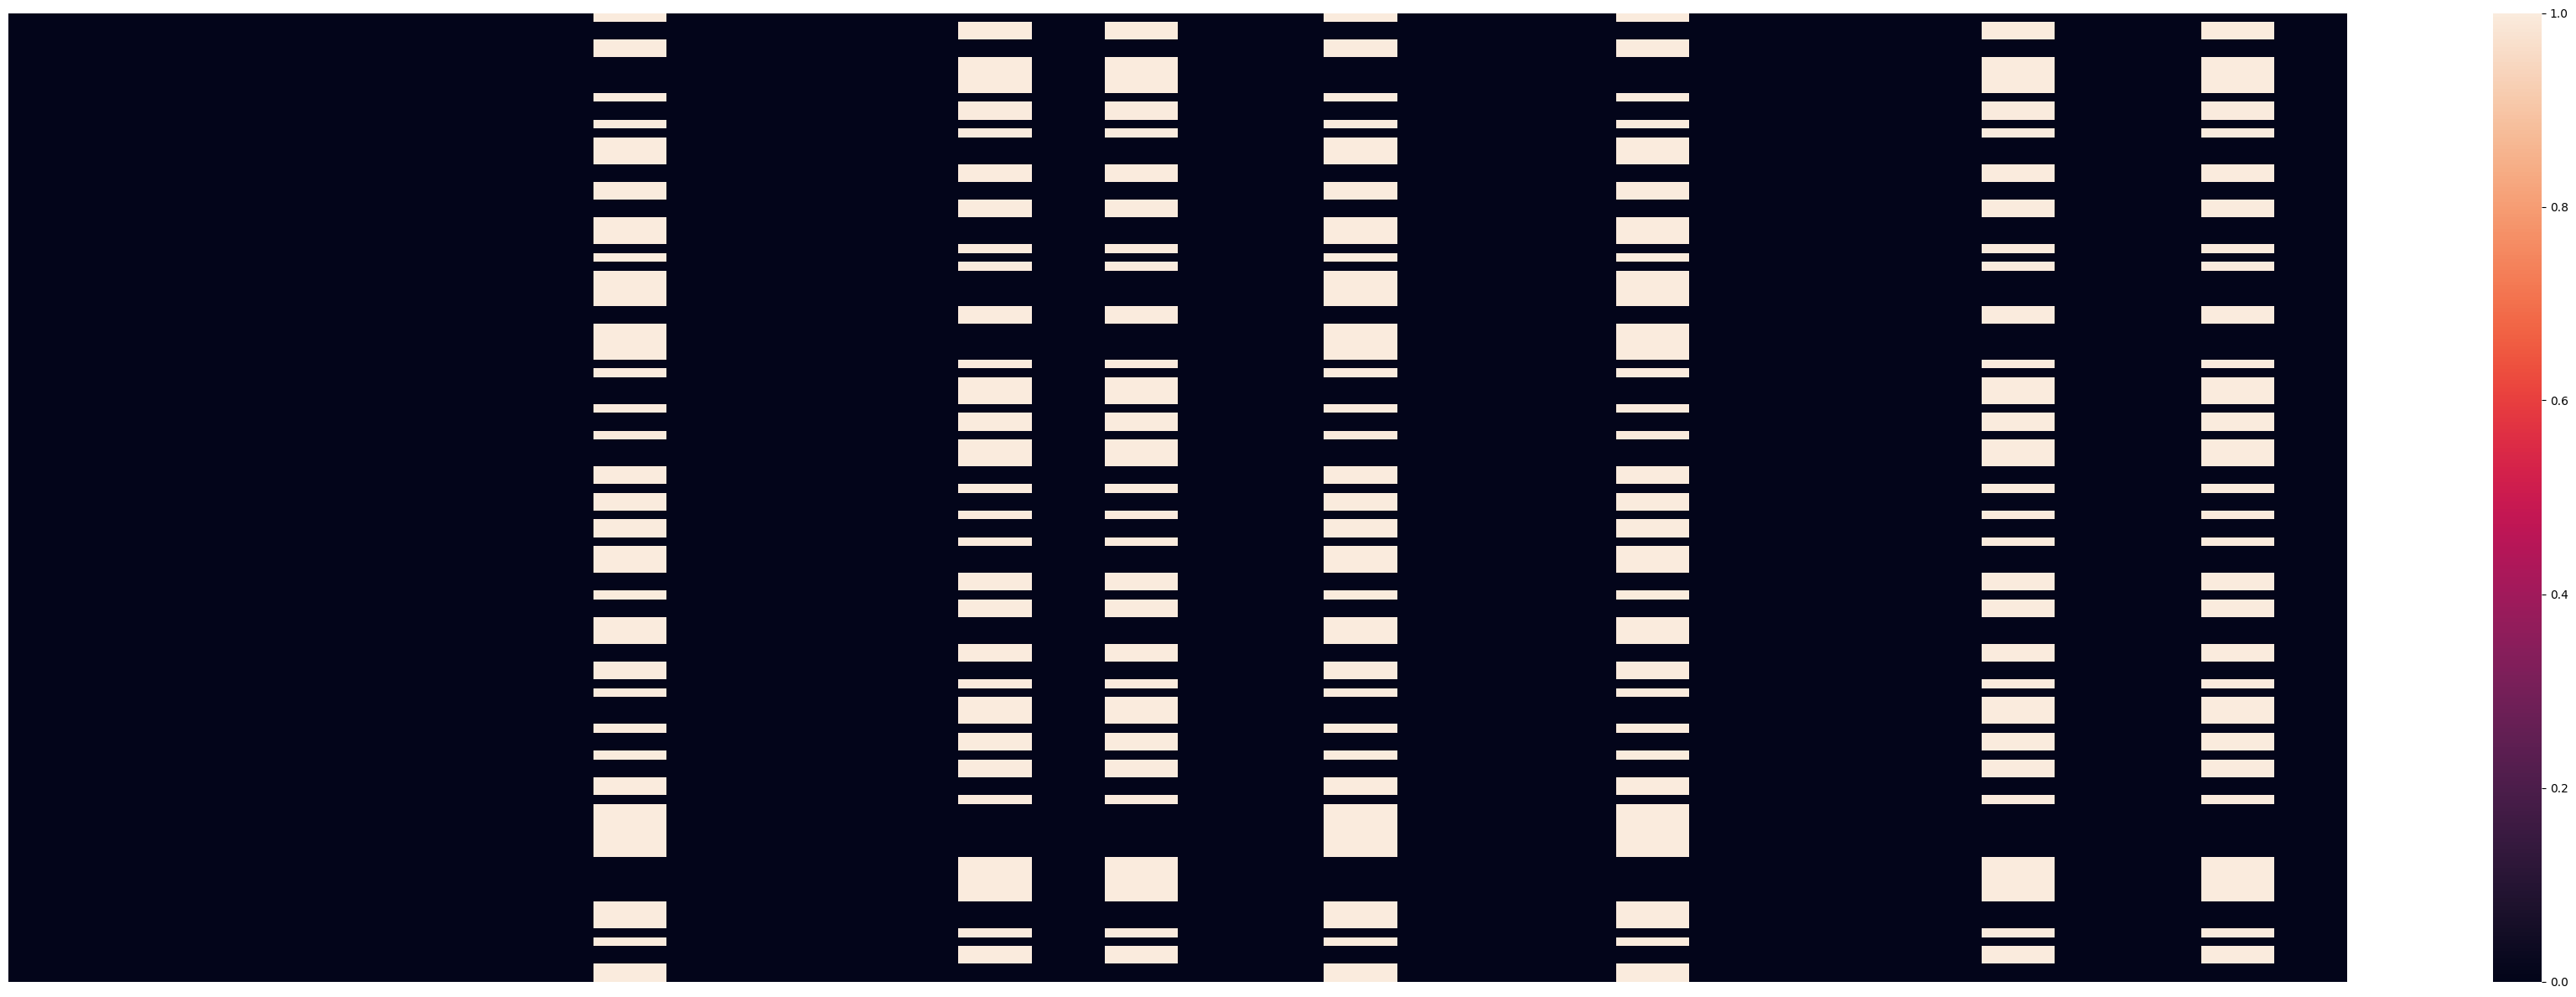

In [24]:
feat_map = mask_3.detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

In [64]:
res_df_2.shape

(128, 20)

In [65]:
res_df_2['prune_ratio'] = 1 - res_df_2['co_params'] / res_df_2['base_params']
res_df_2['prune_ratio'].mean()

np.float64(0.6251324192656837)

In [34]:
res_df_2

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,...,base_ens,co_ens,base_params,co_params,fil_l_1_1,fil_l_1_2,fil_l_1_3,fil_l_2,fil_l_3,prune_ratio
0,ACSF1,91.000000,89.000000,90.000000,88.000000,87.000000,88.000000,87.000000,86.000000,90.000000,...,0.910000,0.880000,10582.0,3775.4,5.6,8.0,13.6,19.6,23.0,0.643224
0,Adiac,81.074169,79.539642,82.608696,75.447570,81.841432,82.097187,82.608696,77.237852,82.352941,...,0.851662,0.792839,11473.0,8369.4,24.0,16.0,18.4,29.6,31.8,0.270513
0,AllGestureWiimoteX,75.857143,64.428571,76.428571,56.285714,75.000000,61.142857,73.714286,57.714286,77.142857,...,0.778571,0.708571,10582.0,6651.6,27.8,18.2,12.4,27.6,13.4,0.371423
0,AllGestureWiimoteY,79.285714,70.571429,79.285714,69.571429,79.000000,69.142857,77.428571,67.285714,78.857143,...,0.804286,0.754286,10582.0,5655.4,24.2,11.0,8.4,27.6,15.0,0.465564
0,AllGestureWiimoteZ,75.857143,56.142857,72.571429,54.285714,72.571429,54.428571,73.714286,53.714286,69.142857,...,0.760000,0.651429,10582.0,4425.4,11.6,10.8,9.6,26.6,13.0,0.581799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Crop,71.744048,69.327381,71.708333,69.869048,71.363095,69.601190,71.595238,68.767857,71.797619,...,0.757321,0.740000,11044.0,11044.0,32.0,32.0,32.0,32.0,32.0,0.000000
0,ElectricDevices,67.098950,65.620542,67.578784,66.087408,68.071586,66.658021,67.928933,64.777590,68.214239,...,0.700298,0.678252,10483.0,8066.4,30.4,24.2,22.0,26.8,22.6,0.230526
0,FordA,95.075758,92.651515,95.606061,93.181818,95.530303,91.439394,95.000000,92.196970,94.924242,...,0.955303,0.938636,10318.0,3858.6,23.0,9.8,4.4,15.0,3.6,0.626032
0,FordB,82.222222,77.407407,83.086420,78.271605,82.098765,77.654321,83.950617,78.271605,82.839506,...,0.840741,0.801235,10318.0,4623.2,25.8,11.6,5.4,20.8,2.4,0.551929


In [66]:
res_df_2['fil_l_1_1'].mean()

np.float64(14.592187500000001)

<Axes: >

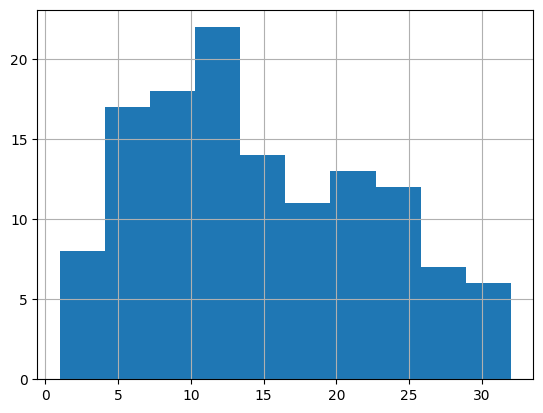

In [67]:
res_df_2['fil_l_1_1'].hist()


In [68]:
res_df_2['fil_l_1_2'].mean()


np.float64(9.1359375)

<Axes: >

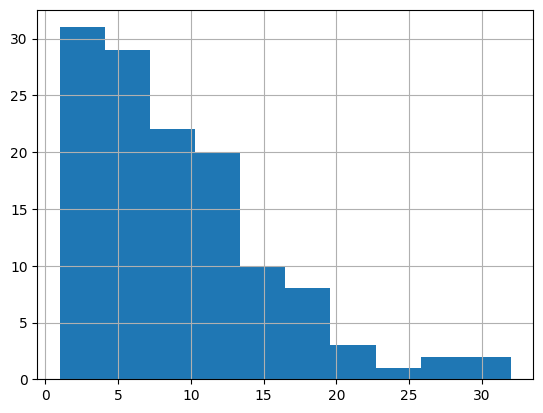

In [69]:
res_df_2['fil_l_1_2'].hist()

In [70]:
res_df_2['fil_l_1_3'].mean()


np.float64(8.565625)

<Axes: >

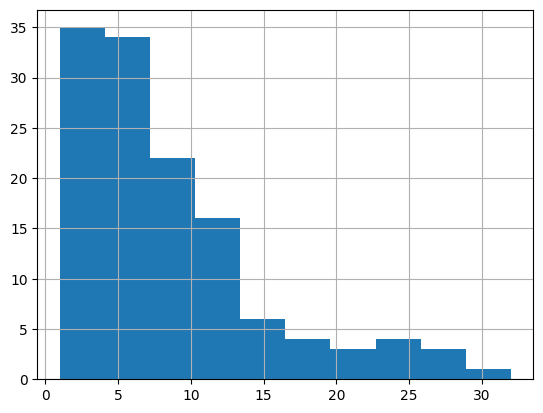

In [71]:
res_df_2['fil_l_1_3'].hist()


In [38]:
res_df_2['fil_l_2'].mean()


np.float64(16.7109375)

<Axes: >

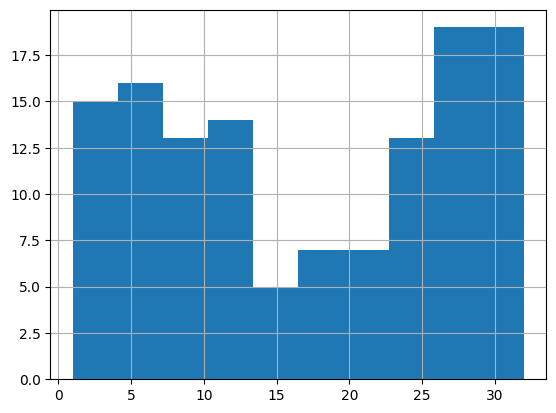

In [43]:
res_df_2['fil_l_2'].hist()


In [39]:
res_df_2['fil_l_3'].mean()


np.float64(12.040625)

<Axes: >

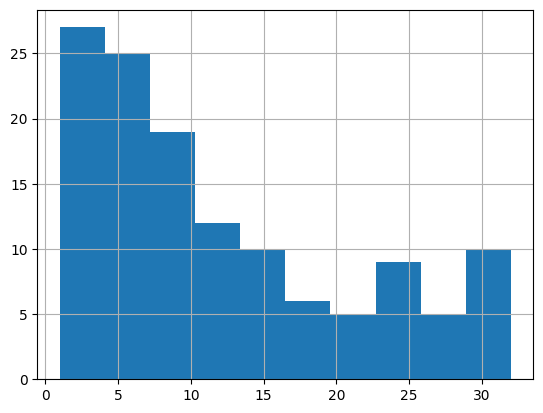

In [44]:
res_df_2['fil_l_3'].hist()


In [30]:
res_df_2

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,co_5,base_ens,co_ens,base_params,co_params,prune_ratio
0,ACSF1,91.000000,89.000000,90.000000,88.000000,87.000000,88.000000,87.000000,86.000000,90.000000,86.000000,0.910000,0.880000,10582.0,3775.4,0.643224
0,Adiac,81.074169,79.539642,82.608696,75.447570,81.841432,82.097187,82.608696,77.237852,82.352941,75.447570,0.851662,0.792839,11473.0,8369.4,0.270513
0,AllGestureWiimoteX,75.857143,64.428571,76.428571,56.285714,75.000000,61.142857,73.714286,57.714286,77.142857,62.714286,0.778571,0.708571,10582.0,6651.6,0.371423
0,AllGestureWiimoteY,79.285714,70.571429,79.285714,69.571429,79.000000,69.142857,77.428571,67.285714,78.857143,68.571429,0.804286,0.754286,10582.0,5655.4,0.465564
0,AllGestureWiimoteZ,75.857143,56.142857,72.571429,54.285714,72.571429,54.428571,73.714286,53.714286,69.142857,48.714286,0.760000,0.651429,10582.0,4425.4,0.581799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Crop,71.744048,69.327381,71.708333,69.869048,71.363095,69.601190,71.595238,68.767857,71.797619,68.833333,0.757321,0.740000,11044.0,11044.0,0.000000
0,ElectricDevices,67.098950,65.620542,67.578784,66.087408,68.071586,66.658021,67.928933,64.777590,68.214239,64.855401,0.700298,0.678252,10483.0,8066.4,0.230526
0,FordA,95.075758,92.651515,95.606061,93.181818,95.530303,91.439394,95.000000,92.196970,94.924242,91.969697,0.955303,0.938636,10318.0,3858.6,0.626032
0,FordB,82.222222,77.407407,83.086420,78.271605,82.098765,77.654321,83.950617,78.271605,82.839506,77.160494,0.840741,0.801235,10318.0,4623.2,0.551929


In [39]:
ucr_df = pd.read_csv('/home/jabdullayev/phd/datasets/ucr_summary.csv')
tmp_df = pd.merge(res_df_2, ucr_df, left_on='Dataset', right_on='Name')
tmp_df

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,...,Name,Train,Test,Class,Length,ED (w=0),DTW (learned_w),DTW (w=100),Default rate,Data donor/editor
0,ACSF1,91.000000,89.000000,90.000000,88.000000,87.000000,88.000000,87.000000,86.000000,90.000000,...,ACSF1,100,100,10,1460,0.4600,0.3800 (4),0.3600,0.9000,P. Schafer
1,Adiac,81.074169,79.539642,82.608696,75.447570,81.841432,82.097187,82.608696,77.237852,82.352941,...,Adiac,390,391,37,176,0.3887,0.3913 (3),0.3964,0.9591,A. Jalba
2,AllGestureWiimoteX,75.857143,64.428571,76.428571,56.285714,75.000000,61.142857,73.714286,57.714286,77.142857,...,AllGestureWiimoteX,300,700,10,Vary,0.4843,0.2829 (14),0.2843,0.9000,J. Guna
3,AllGestureWiimoteY,79.285714,70.571429,79.285714,69.571429,79.000000,69.142857,77.428571,67.285714,78.857143,...,AllGestureWiimoteY,300,700,10,Vary,0.4314,0.2700 (9),0.2714,0.9000,J. Guna
4,AllGestureWiimoteZ,75.857143,56.142857,72.571429,54.285714,72.571429,54.428571,73.714286,53.714286,69.142857,...,AllGestureWiimoteZ,300,700,10,Vary,0.5457,0.3486 (11),0.3571,0.9000,J. Guna
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Crop,71.744048,69.327381,71.708333,69.869048,71.363095,69.601190,71.595238,68.767857,71.797619,...,Crop,7200,16800,24,46,0.2883,0.2883 (0),0.3348,0.9583,F. Petitjean
124,ElectricDevices,67.098950,65.620542,67.578784,66.087408,68.071586,66.658021,67.928933,64.777590,68.214239,...,ElectricDevices,8926,7711,7,96,0.4492,0.3806 (14),0.3988,0.7463,A. Bagnall & J. Lines
125,FordA,95.075758,92.651515,95.606061,93.181818,95.530303,91.439394,95.000000,92.196970,94.924242,...,FordA,3601,1320,2,500,0.3348,0.3091 (1),0.4455,0.4841,A. Bagnall
126,FordB,82.222222,77.407407,83.086420,78.271605,82.098765,77.654321,83.950617,78.271605,82.839506,...,FordB,3636,810,2,500,0.3938,0.3926 (1),0.3802,0.4951,A. Bagnall


In [ ]:
res_df_2[res_df_2['prune_ratio'] > 0.66].shape

In [44]:
res_df_2[res_df_2['prune_ratio'] < 0.5].shape

(35, 16)

In [42]:
tmp_df[tmp_df['prune_ratio'] < 0.5]

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,...,Name,Train,Test,Class,Length,ED (w=0),DTW (learned_w),DTW (w=100),Default rate,Data donor/editor
1,Adiac,81.074169,79.539642,82.608696,75.447570,81.841432,82.097187,82.608696,77.237852,82.352941,...,Adiac,390,391,37,176,0.3887,0.3913 (3),0.3964,0.9591,A. Jalba
2,AllGestureWiimoteX,75.857143,64.428571,76.428571,56.285714,75.000000,61.142857,73.714286,57.714286,77.142857,...,AllGestureWiimoteX,300,700,10,Vary,0.4843,0.2829 (14),0.2843,0.9000,J. Guna
3,AllGestureWiimoteY,79.285714,70.571429,79.285714,69.571429,79.000000,69.142857,77.428571,67.285714,78.857143,...,AllGestureWiimoteY,300,700,10,Vary,0.4314,0.2700 (9),0.2714,0.9000,J. Guna
8,Beef,73.333333,50.000000,70.000000,63.333333,73.333333,60.000000,70.000000,63.333333,73.333333,...,Beef,30,30,5,470,0.3333,0.3333 (0),0.3667,0.8000,K. Kemsley & A. Bagnall
13,ChlorineConcentration,83.515625,78.489583,82.630208,76.718750,83.385417,78.203125,85.078125,76.953125,84.661458,...,ChlorineConcentration,467,3840,3,166,0.3500,0.3500 (0),0.3516,0.4674,L. Li & C. Faloutsos
17,CricketX,82.564103,73.333333,80.000000,67.435897,81.794872,70.512821,83.076923,71.794872,82.307692,...,CricketX,390,390,12,300,0.4231,0.2282 (10),0.2462,0.8974,A. Mueen & E. Keogh
19,CricketZ,84.615385,66.666667,83.589744,69.743590,84.615385,69.230769,85.897436,69.487179,85.128205,...,CricketZ,390,390,12,300,0.4128,0.2538 (5),0.2462,0.8974,A. Mueen & E. Keogh
21,DistalPhalanxOutlineAgeGroup,76.978417,71.942446,71.223022,69.784173,67.625899,74.100719,73.381295,72.661871,70.503597,...,DistalPhalanxOutlineAgeGroup,400,139,3,80,0.3741,0.3741 (0),0.2302,0.5324,L. Davis & A. Bagnall
23,DistalPhalanxTW,67.625899,66.187050,67.625899,68.345324,65.467626,64.748201,66.906475,66.906475,70.503597,...,DistalPhalanxTW,400,139,6,80,0.3669,0.3669 (0),0.4101,0.6978,L. Davis & A. Bagnall
24,DodgerLoopDay,58.750000,43.750000,62.500000,42.500000,56.250000,37.500000,56.250000,41.250000,62.500000,...,DodgerLoopDay,78,80,7,288,0.4500,0.4125 (1),0.5000,0.8375,C.-C. M. Yeh


<Axes: >

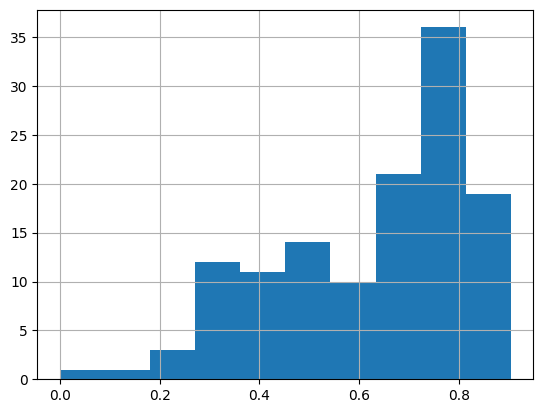

In [23]:
res_df_2['prune_ratio'].hist()

In [24]:
res_df_2[res_df_2['prune_ratio'] > 0.6].shape

(78, 16)

p_value:  6.007749007559193e-18


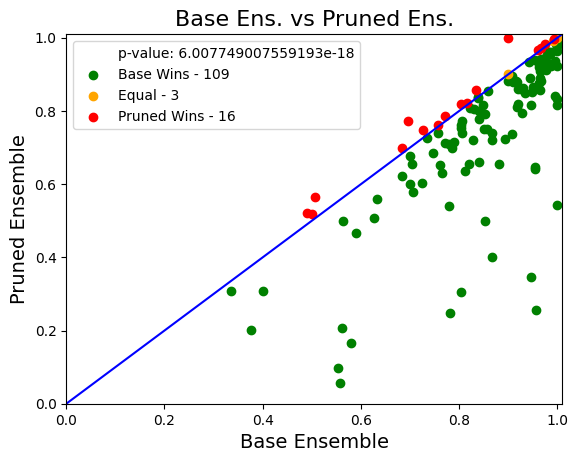

In [25]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df_2['base_ens'].tolist(), res_df_2['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df_2, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens.', 
              file_name=None)

p_value:  6.676812000997235e-14


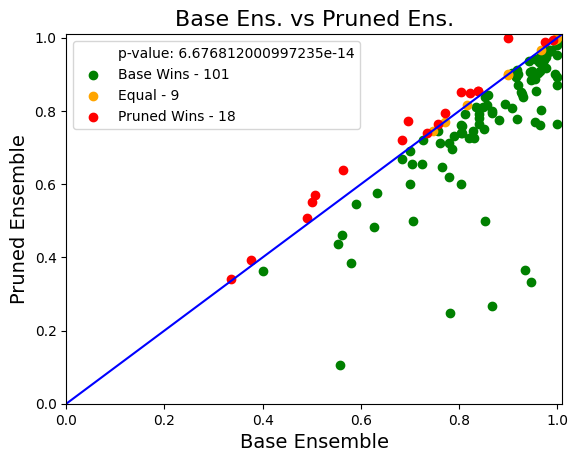

In [7]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df_2['base_ens'].tolist(), res_df_2['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df_2, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens.', 
              file_name=None)

p_value:  2.1516675632261555e-20


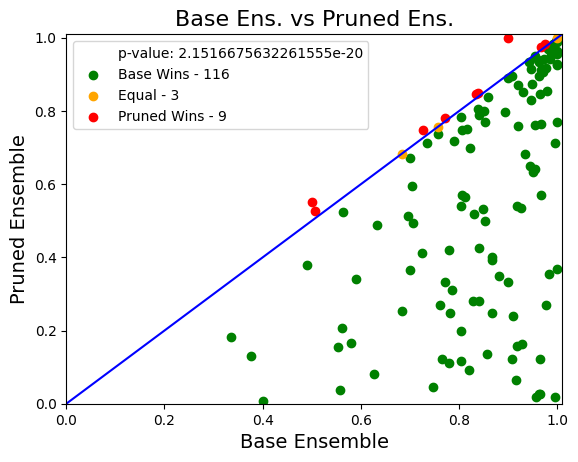

In [11]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df_2['base_ens'].tolist(), res_df_2['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df_2, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens.', 
              file_name=None)

In [26]:

seeds = [9409, 3804, 3952, 2561, 5296]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens']
res_df = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))

    models_base, models_base_norm, models_pruned = [], [], []
    
    for seed in seeds:
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        print(sum(p.numel() for p in model_base.parameters()))
        
        model_pruned = torch.load(os.getcwd() + f'/results/scratch_training_2e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        # model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
        models_pruned.append(model_pruned)
        rows.append(pd.read_csv(os.getcwd() + f'/results/scratch_training_2e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
    
    ens_acc_base = evaluate_ensemble_base(models_base, testloader)
    rows.append(ens_acc_base)

    ens_acc_base = evaluate_ensemble_base(models_pruned, testloader)
    rows.append(ens_acc_base)

    res_df = pd.concat([res_df, pd.DataFrame([rows], columns=columns)])


10582
10582
10582
10582
10582

Ensemble Accuracy: 0.9100

Ensemble Accuracy: 0.9100
11473
11473
11473
11473
11473

Ensemble Accuracy: 0.8517

Ensemble Accuracy: 0.8465
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7786

Ensemble Accuracy: 0.7814
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.8043

Ensemble Accuracy: 0.7871
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7600

Ensemble Accuracy: 0.7543
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.8057

Ensemble Accuracy: 0.8000
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.8500

Ensemble Accuracy: 0.9000
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.9000

Ensemble Accuracy: 0.9000
10417
10417
10417
10417
10417

Ensemble Accuracy: 0.7000

Ensemble Accuracy: 0.7333
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9467

Ensemble Accuracy: 0.9733
10384
10384
10384
10384
10384

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.9333
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9989

Ensemble Accuracy:

p_value:  0.06341314542353632


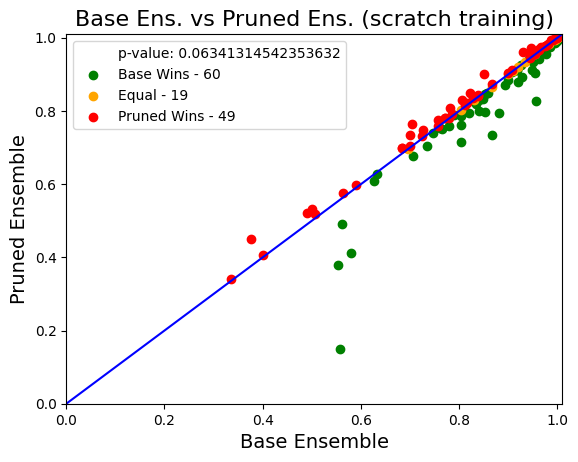

In [27]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens. (scratch training)', 
              file_name=None)

In [131]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]
seeds = [9409, 3804, 3952, 2561, 5296]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens']
res_df = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))

    models_base, models_base_norm, models_pruned = [], [], []
    
    for seed in seeds:
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        print(sum(p.numel() for p in model_base.parameters()))
        
        # model_pruned = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        model_pruned = torch.load(os.getcwd() + f'/results/finetune_1e-5_weights_4_2_1_with_lr_scheduler_epochs_500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        # model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
        models_pruned.append(model_pruned)
        # rows.append(pd.read_csv(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        rows.append(pd.read_csv(os.getcwd() + f'/results/finetune_1e-5_weights_4_2_1_with_lr_scheduler_epochs_500/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
    
    ens_acc_base = evaluate_ensemble_base(models_base, testloader)
    rows.append(ens_acc_base)

    ens_acc_base = evaluate_ensemble_base(models_pruned, testloader)
    rows.append(ens_acc_base)

    res_df = pd.concat([res_df, pd.DataFrame([rows], columns=columns)])

10582
10582
10582
10582
10582

Ensemble Accuracy: 0.9100

Ensemble Accuracy: 0.9100
11473
11473
11473
11473
11473

Ensemble Accuracy: 0.8517

Ensemble Accuracy: 0.8465
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7786

Ensemble Accuracy: 0.7243
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.8043

Ensemble Accuracy: 0.7671
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7600

Ensemble Accuracy: 0.7271
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.8057

Ensemble Accuracy: 0.7943
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.8500

Ensemble Accuracy: 0.7000
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.9000

Ensemble Accuracy: 0.9500
10417
10417
10417
10417
10417

Ensemble Accuracy: 0.7000

Ensemble Accuracy: 0.7000
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9467

Ensemble Accuracy: 0.9800
10384
10384
10384
10384
10384

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.9167
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9989

Ensemble Accuracy:

In [132]:
res_df.shape

(128, 13)

p_value:  9.342334615746843e-11


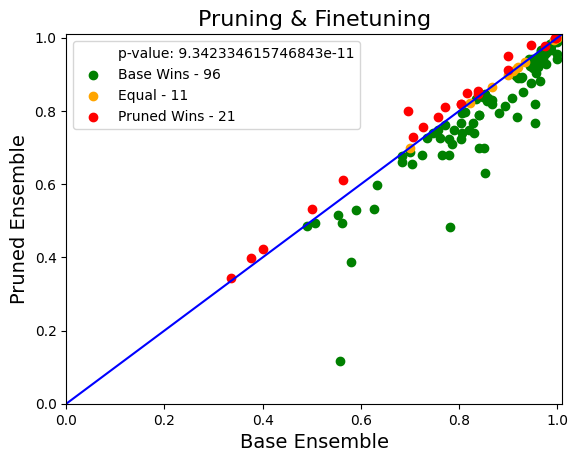

In [134]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Pruning & Finetuning', 
              file_name='pretraining_vs_base_1v1')

p_value:  1.3739453682390856e-10


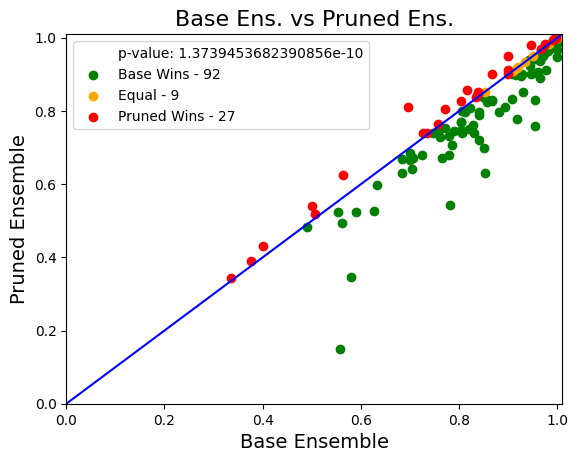

In [8]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens.', 
              file_name='pretraining_vs_base_1v1')

In [ ]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]
seeds = [9409, 3804, 3952, 2561, 5296]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens', 'base_params', 'co_params']
res_df = pd.DataFrame(columns=columns)

for dataset in ds_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))

    models_base, models_base_12, models_base_norm, models_pruned = [], [], [], []
    base_params, base_12_params, co_params = 0, 0, 0

    for seed in seeds:
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        base_params += sum(p.numel() for p in model_base.parameters())
        
        model_base_12 = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[12, 12, 12], 12, 12])
        model_base_12.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_12_filters/base_seed_{seed}/{dataset}/best_model.pt'))
        models_base_12.append(model_base_12)
        rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_12_filters/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        base_12_params += sum(p.numel() for p in model_base_12.parameters())

        model_pruned = torch.load(os.getcwd() + f'/results/scratch_training_2e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_pruned.append(model_pruned)
        rows.append(pd.read_csv(os.getcwd() + f'/results/scratch_training_2e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        co_params += sum(p.numel() for p in model_pruned.parameters())
    
    ens_acc_base = evaluate_ensemble_base(models_base, testloader)
    rows.append(ens_acc_base)

    ens_acc_base = evaluate_ensemble_base(models_base_12, testloader)
    rows.append(ens_acc_base)

    base_params /= 5
    co_params /= 5
    
    rows.append(base_params)
    rows.append(co_params)
    
    res_df = pd.concat([res_df, pd.DataFrame([rows], columns=columns)])



Ensemble Accuracy: 0.9100

Ensemble Accuracy: 0.9000

Ensemble Accuracy: 0.8517

Ensemble Accuracy: 0.8107

Ensemble Accuracy: 0.7786

Ensemble Accuracy: 0.7614

Ensemble Accuracy: 0.8043

Ensemble Accuracy: 0.7943

Ensemble Accuracy: 0.7600

Ensemble Accuracy: 0.7257

Ensemble Accuracy: 0.8057

Ensemble Accuracy: 0.8171

Ensemble Accuracy: 0.8500

Ensemble Accuracy: 0.8500

Ensemble Accuracy: 0.9000

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.7000

Ensemble Accuracy: 0.7667

Ensemble Accuracy: 0.9467

Ensemble Accuracy: 0.9600

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.9989

Ensemble Accuracy: 0.9989

Ensemble Accuracy: 0.9854

Ensemble Accuracy: 0.9796

Ensemble Accuracy: 0.8492

Ensemble Accuracy: 0.8401

Ensemble Accuracy: 0.8667

Ensemble Accuracy: 0.8841

Ensemble Accuracy: 1.0000

Ensemble Accuracy: 1.0000

Ensemble Accuracy: 0.8120

Ensemble Accuracy: 0.8200

Ensemble Accuracy: 0.8410

Ensemble Accuracy: 0.8179

Ensemble Accuracy: 0.8564



In [51]:
res_df

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,co_5,base_ens,co_ens,base_params,co_params
0,ACSF1,91.000000,90.000000,90.000000,88.000000,87.000000,87.000000,87.000000,89.000000,90.000000,88.000000,0.910000,0.900000,10582.0,3522.0
0,Adiac,81.074169,76.982097,82.608696,79.028133,81.841432,77.749361,82.608696,76.982097,82.352941,78.516624,0.851662,0.810742,11473.0,3873.0
0,AllGestureWiimoteX,75.857143,69.285714,76.428571,68.142857,75.000000,68.714286,73.714286,68.857143,77.142857,70.428571,0.778571,0.761429,10582.0,3522.0
0,AllGestureWiimoteY,79.285714,76.000000,79.285714,71.857143,79.000000,74.428571,77.428571,74.285714,78.857143,75.571429,0.804286,0.794286,10582.0,3522.0
0,AllGestureWiimoteZ,75.857143,65.714286,72.571429,65.714286,72.571429,63.571429,73.714286,62.571429,69.142857,64.714286,0.760000,0.725714,10582.0,3522.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Crop,71.744048,68.690476,71.708333,68.827381,71.363095,68.529762,71.595238,68.547619,71.797619,68.750000,0.757321,0.740179,11044.0,3704.0
0,ElectricDevices,67.098950,68.019712,67.578784,68.434704,68.071586,67.799248,67.928933,64.777590,68.214239,67.760342,0.700298,0.703151,10483.0,3483.0
0,FordA,95.075758,95.151515,95.606061,95.530303,95.530303,95.454545,95.000000,94.696970,94.924242,95.151515,0.955303,0.959091,10318.0,3418.0
0,FordB,82.222222,82.345679,83.086420,81.975309,82.098765,81.975309,83.950617,82.098765,82.839506,82.469136,0.840741,0.832099,10318.0,3418.0


In [52]:
res_df['prune_ratio'] = 1 - res_df['co_params'] / res_df['base_params']


In [53]:
res_df['prune_ratio'].mean()

np.float64(0.667491634276913)

p_value:  0.8574205095135521


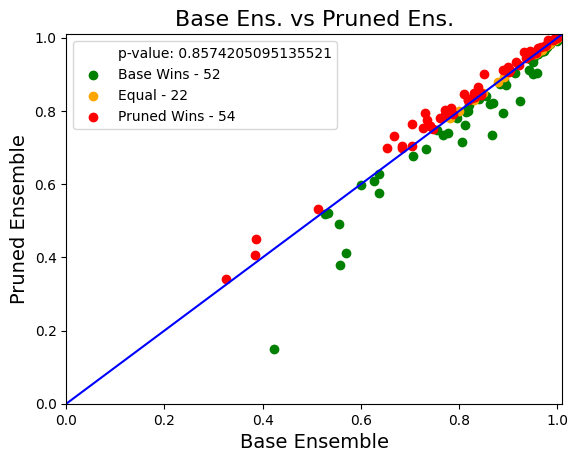

In [29]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens.', 
              file_name='finetuning_vs_base_1v1')

p_value:  0.047693976906919795


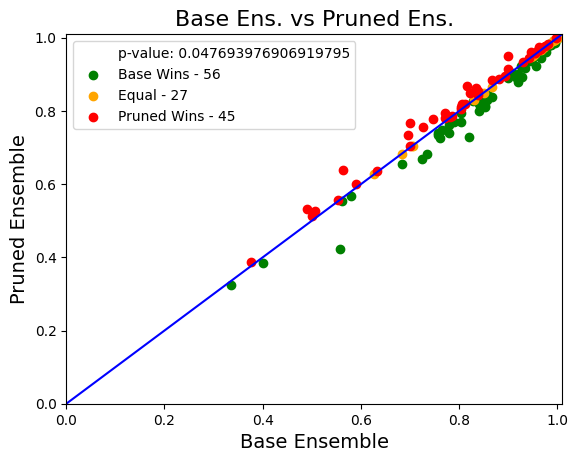

In [12]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens.', 
              file_name='finetuning_vs_base_1v1')

In [32]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]
seeds = [9409, 3804, 3952, 2561, 5296]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens']
res_df = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))

    models_base, models_base_norm, models_base_small = [], [], []
    
    for seed in seeds:
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        print(sum(p.numel() for p in model_base.parameters()))
        
        model_base_small = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[16, 16, 16], 16, 16])
        model_base_small.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_16_filters/base_seed_{seed}/{dataset}/best_model.pt'))
        # model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
        models_base_small.append(model_base_small)
        rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_16_filters/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
    
    ens_acc_base = evaluate_ensemble_base(models_base, testloader)
    rows.append(ens_acc_base)

    ens_acc_base = evaluate_ensemble_base(models_base_small, testloader)
    rows.append(ens_acc_base)

    res_df = pd.concat([res_df, pd.DataFrame([rows], columns=columns)])


10582
10582
10582
10582
10582

Ensemble Accuracy: 0.9100

Ensemble Accuracy: 0.8900
11473
11473
11473
11473
11473

Ensemble Accuracy: 0.8517

Ensemble Accuracy: 0.8338
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7786

Ensemble Accuracy: 0.7771
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.8043

Ensemble Accuracy: 0.8000
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7600

Ensemble Accuracy: 0.7414
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.8057

Ensemble Accuracy: 0.8229
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.8500

Ensemble Accuracy: 0.8000
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.9000

Ensemble Accuracy: 0.9000
10417
10417
10417
10417
10417

Ensemble Accuracy: 0.7000

Ensemble Accuracy: 0.7667
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9467

Ensemble Accuracy: 0.9400
10384
10384
10384
10384
10384

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.9500
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9989

Ensemble Accuracy:

p_value:  0.004384772778849952


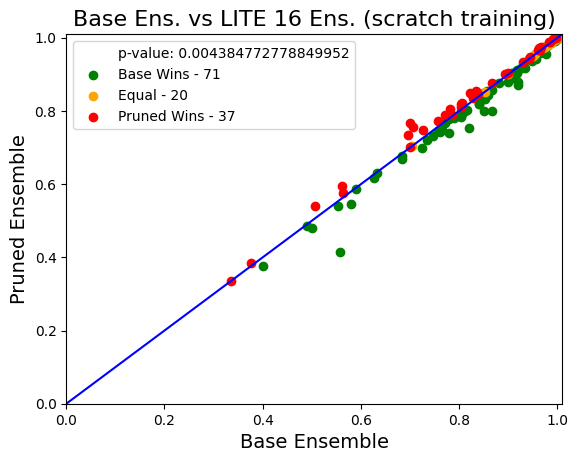

In [33]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs LITE 16 Ens. (scratch training)', 
              file_name=None)

p_value:  0.047693976906919795


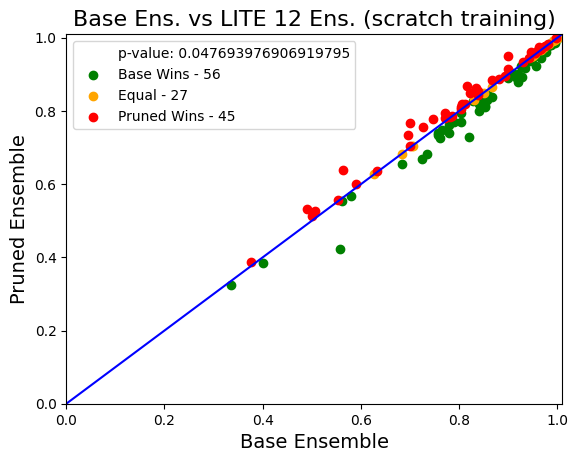

In [28]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs LITE 12 Ens. (scratch training)', 
              file_name=None)

p_value:  0.004098467314645138


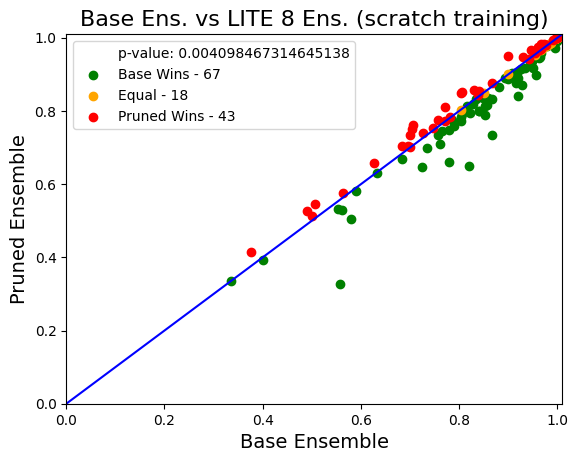

In [31]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs LITE 8 Ens. (scratch training)', 
              file_name=None)

p_value:  0.3715471583324427


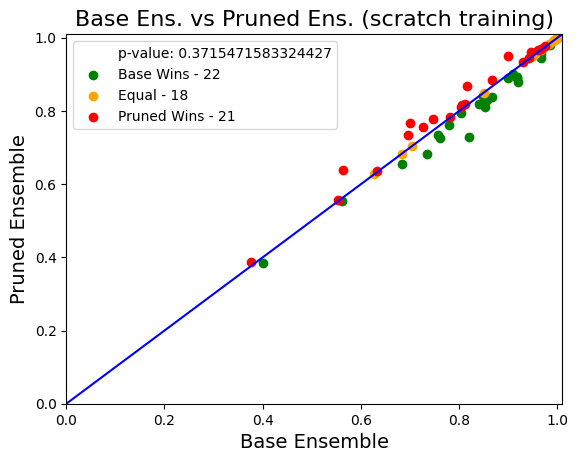

In [13]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs Pruned Ens. (scratch training)', 
              file_name=None)

## Feature map visualization

In [60]:
dataset_names = ['Crop']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    
    model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    # model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    model_base.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_2e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
    
    features_dict = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for b_idx, (input, target) in enumerate(trainloader):
            input, target = input.cuda(), target.cuda()
            output, features = model_base.forward_sparsity(input.float())
            features_dict[1].append(features[0][:, :96, :])
            features_dict[2].append(features[1])
            features_dict[3].append(features[2])

    features_dict[1] = torch.cat(features_dict[1], dim=0)
    features_dict[2] = torch.cat(features_dict[2], dim=0)
    features_dict[3] = torch.cat(features_dict[3], dim=0)

In [63]:
target

tensor([ 2, 13, 11, 18,  7,  9, 11, 14, 21,  7,  1, 10, 20, 22, 19, 21, 16,  2,
        15,  4, 19, 13, 18, 14, 20, 16, 16, 15,  0,  8, 10, 15],
       device='cuda:0')

feat map shape:  torch.Size([32, 46])


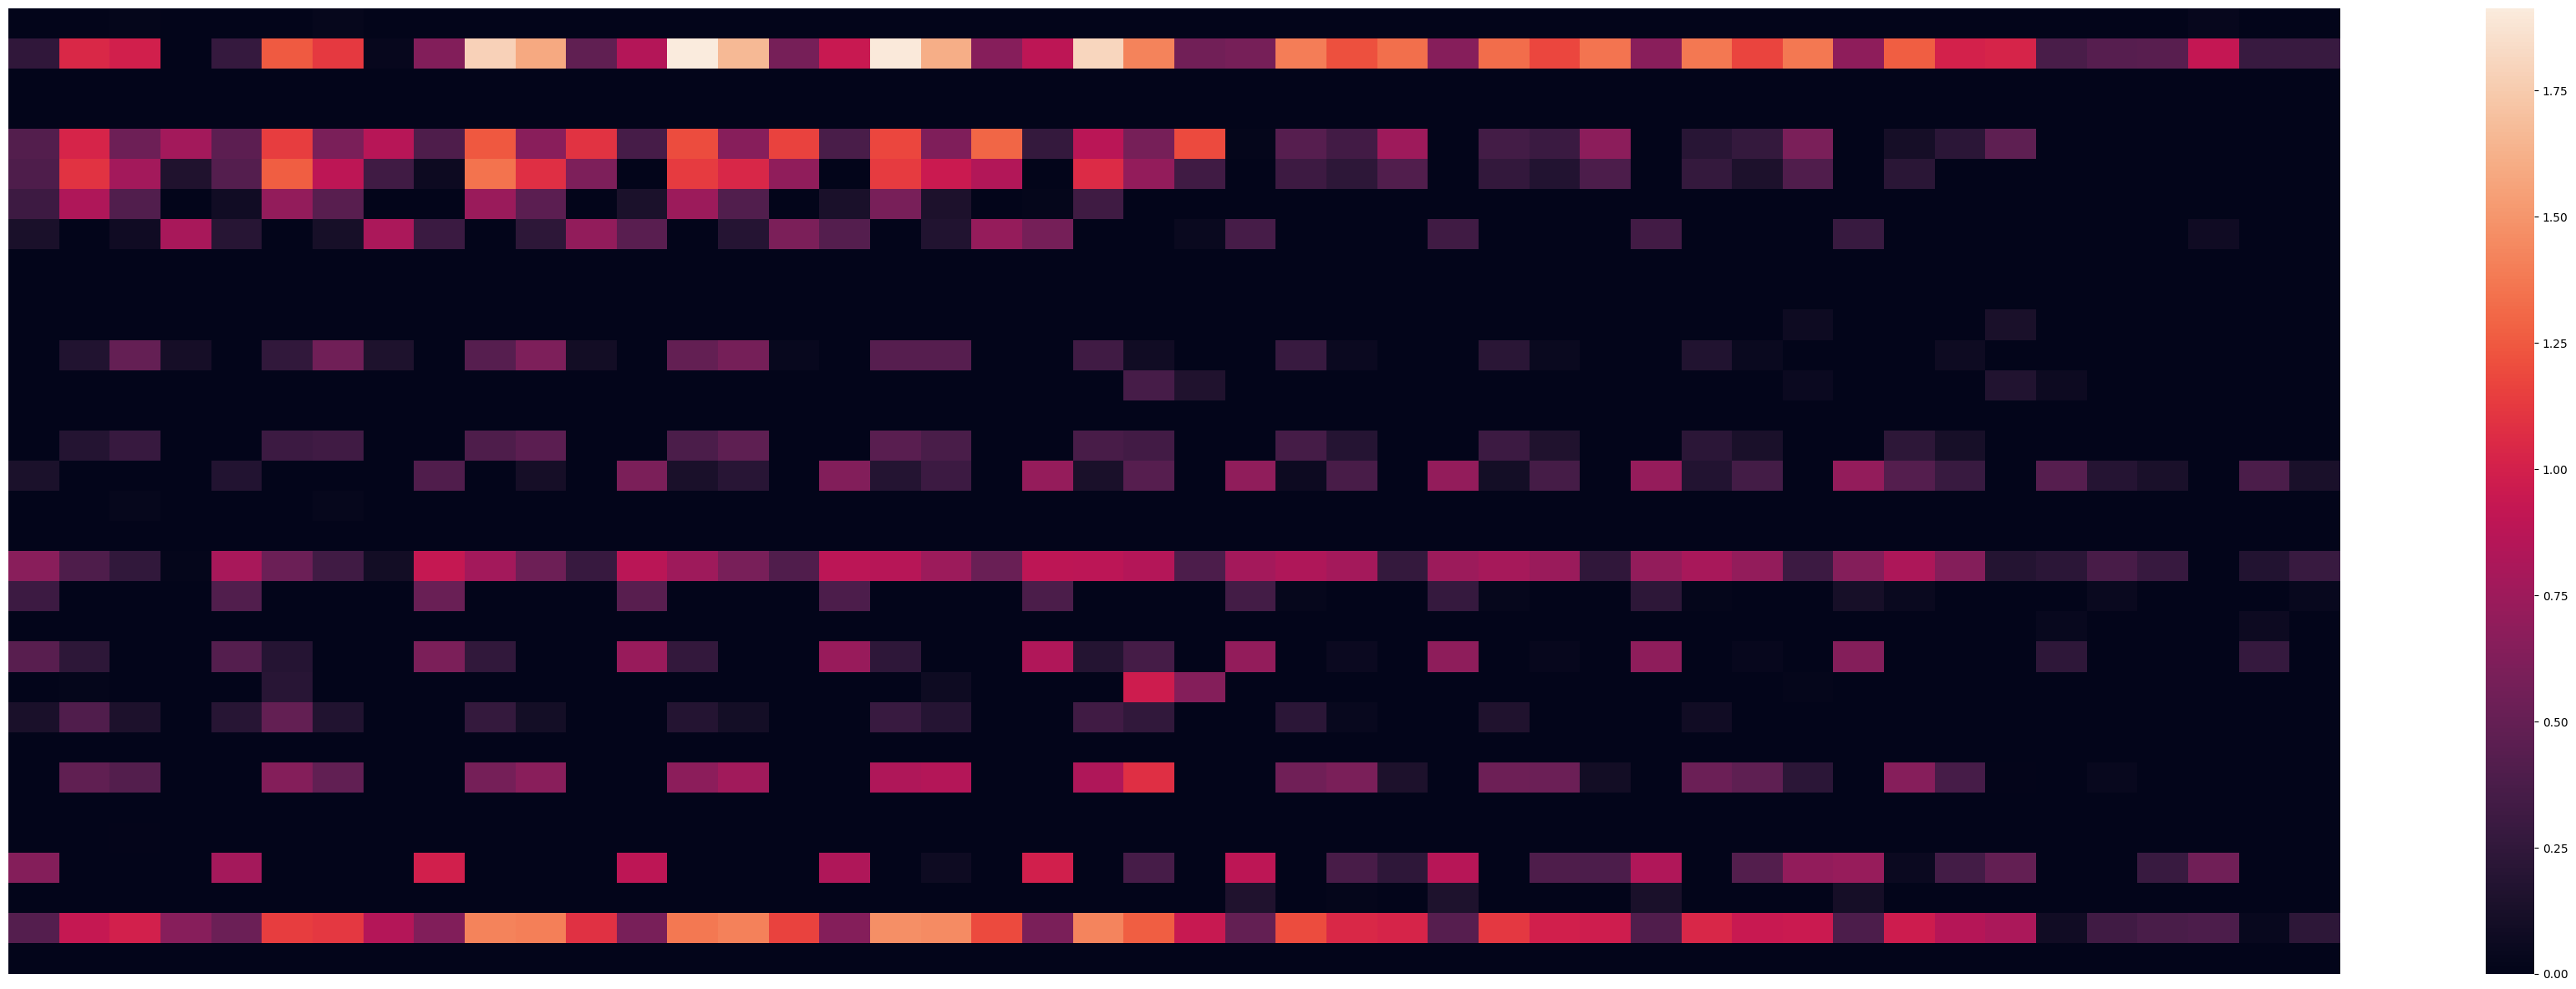

In [62]:
feat_map = features_dict[3][12].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

In [8]:
import torch.nn.functional as F

def calculate_redundancy(feature_map, threshold=0.95):
    # print('Feature map shape: ', feature_map.shape)
    num_samples, num_channels, ts_len = feature_map.shape
    activation_strength = torch.norm(feature_map, p=1, dim=-1)
    # print('activation_strength shape: ', activation_strength.shape)
    # 
    mean_activation = activation_strength.mean(dim=-1, keepdims=True)
    # print('mean_activation: ', mean_activation)
    mask = (activation_strength > mean_activation)
    # print('mask shape: ', mask.shape)
    
    
    total_sum = 0
    for i in range(num_samples): # loop over each sample
        x = feature_map[i][mask[i]]
        x_norm = F.normalize(x, p=2, dim=1)

        # print('x_norm shape: ', x_norm.shape)
        
        from numpy.linalg import svd
        from scipy.stats import entropy
        S = svd(x.detach().cpu(), compute_uv=False)
        P = S / np.sum(S)
        
        print('S: ', S)
        total_sum += np.exp(entropy(P)) / len(S)


    total_sum /= num_samples
    return total_sum

import torch
import torch.nn.functional as F
from numpy.linalg import svd
from scipy.stats import entropy
import numpy as np

def calculate_redundancy_2(feature_map, threshold=0.95, zero_eps=1e-6):
    num_samples, num_channels, ts_len = feature_map.shape
    energy_ratios = []
    effective_ranks = []

    for i in range(num_samples):
        # Select active filters based on L1 norm
        activation_strength = torch.norm(feature_map[i], p=1, dim=-1)
        mean_activation = activation_strength.mean()
        mask = (activation_strength > mean_activation)
        
        if mask.sum() < 2:
            continue  # not enough active filters to compute redundancy

        x = feature_map[i][mask]
        x_norm = F.normalize(x, p=2, dim=1)
        x_np = x_norm.detach().cpu().numpy()

        # Singular values
        S = svd(x_np, compute_uv=False)

        # Energy Coverage
        energy = S ** 2
        cumulative = np.cumsum(energy) / np.sum(energy)
        k = np.searchsorted(cumulative, threshold) + 1
        energy_ratio = k / len(S)

        # Effective Rank
        P = S / (np.sum(S) + zero_eps)
        eff_rank = np.exp(entropy(P)) / len(S)

        # Save both
        energy_ratios.append(energy_ratio)
        effective_ranks.append(eff_rank)

        print(f"Sample {i}:")
        print("  S =", S)
        print("  Energy coverage ratio =", energy_ratio)
        print("  Effective rank =", eff_rank)

    avg_energy_ratio = np.mean(energy_ratios) if energy_ratios else 0
    avg_eff_rank = np.mean(effective_ranks) if effective_ranks else 0

    return avg_energy_ratio, avg_eff_rank


def calculate_redundancy_3(feature_map, threshold=0.95):
    # print('Feature map shape: ', feature_map.shape)
    num_samples, num_channels, ts_len = feature_map.shape
    activation_strength = torch.norm(feature_map, p=1, dim=-1)
    # print('activation_strength shape: ', activation_strength.shape)
    # 
    mean_activation = activation_strength.mean(dim=-1, keepdims=True)
    # print('mean_activation: ', mean_activation)
    mask = (activation_strength > mean_activation)
    # print('mask shape: ', mask.shape)
    
    
    total_sum = 0
    for i in range(num_samples): # loop over each sample
        x = feature_map[i]
        x_norm = F.normalize(x, p=2, dim=1)

        
        total_sum += avg_mutual_information(x_norm)

    total_sum /= num_samples
    return total_sum



from sklearn.metrics import mutual_info_score

def avg_mutual_information(active, activation_threshold=1e-5, bins=16):
    active = active.detach().cpu()
    active_discrete = np.digitize(active, bins=np.histogram_bin_edges(active, bins=bins))
    n = active_discrete.shape[0]
    total_mi = 0
    count = 0

    for i in range(n):
        for j in range(i+1, n):
            mi = mutual_info_score(active_discrete[i], active_discrete[j])
            total_mi += mi
            count += 1

    return total_mi

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

from lite_org import LITE
from utils import load_data, preprocess_data
import os
from  utils import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

dataset_names = ['ShapeletSim']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
# columns=['Dataset', 'base_red_3',  'sparse_red_3',]

redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    
    model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    # model_base.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
     
    
    features_dict = {1: [], 2: [], 3: []}

    # with torch.no_grad():
    #     for b_idx, (input, target) in enumerate(trainloader):
    #         input, target = input.cuda(), target.cuda()
    #         output, features = model_base.forward_sparsity(input.float())
    #         features_dict[1].append(features[0][:, :96, :])
    #         features_dict[2].append(features[1])
    #         features_dict[3].append(features[2])

    # features_dict[1] = torch.cat(features_dict[1], dim=0)
    # features_dict[2] = torch.cat(features_dict[2], dim=0)
    # features_dict[3] = torch.cat(features_dict[3], dim=0)
    

    # print(features_dict[1].shape)
    # print(features_dict[2].shape)
    # print(features_dict[3].shape)
    
    # redundancy_amount_layer_1 = calculate_redundancy_3(features_dict[1])
    # redundancy_amount_layer_2 = calculate_redundancy_3(features_dict[2])
    # redundancy_amount_layer_3 = calculate_redundancy_3(features_dict[3])
    # print('redundancy_amount_layer_3: ', redundancy_amount_layer_3)
    
    # rows.append(redundancy_amount_layer_1)
    # rows.append(redundancy_amount_layer_2)
    # rows.append(redundancy_amount_layer_3)
    
    
    print('\n-----------------------------------------------------------------------------------------------------------\n')
    
    # print('Redundancy in the first layer: ', redundancy_amount_layer_1)
    # print('Redundancy in the second layer: ', redundancy_amount_layer_2)
    # print('Redundancy in the third layer: ', redundancy_amount_layer_3)
    
    
    # print('\n\n')
    # print('Redundancy amount for the sparse base model')
    model_dsp = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    # if model_dsp.fcn_module2.depthwise_conv.weight.shape[0] == 2:
        
    #     print(f'Dataset: => {dataset}')
    #     break
    # print(f'weight shape: {model_dsp.fcn_module2.depthwise_conv.weight.shape}')
    
    # model_base = model_dsp
    # model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    # model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    # model_base.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
    
    
    features_dict = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for b_idx, (input, target) in enumerate(trainloader):
            input, target = input.cuda(), target.cuda()
            output, features = model_base.forward_sparsity(input.float())
            features_dict[1].append(features[0][:, :96, :])
            features_dict[2].append(features[1])
            features_dict[3].append(features[2])

    features_dict[1] = torch.cat(features_dict[1], dim=0)
    features_dict[2] = torch.cat(features_dict[2], dim=0)
    features_dict[3] = torch.cat(features_dict[3], dim=0)
    

    print(features_dict[1].shape)
    print(features_dict[2].shape)
    print(features_dict[3].shape)
    
    # redundancy_amount_layer_1 = calculate_redundancy_3(features_dict[1])
    # redundancy_amount_layer_2 = calculate_redundancy_3(features_dict[2])
    # redundancy_amount_layer_3 = calculate_redundancy_3(features_dict[3])
    # print('redundancy_amount_layer_3: ', redundancy_amount_layer_3)
    
    # rows.append(redundancy_amount_layer_1)
    # rows.append(redundancy_amount_layer_2)
    # rows.append(redundancy_amount_layer_3)

    
    # print('Redundancy in the first layer: ', redundancy_amount_layer_1)
    # print('Redundancy in the second layer: ', redundancy_amount_layer_2)
    # print('Redundancy in the third layer: ', redundancy_amount_layer_3)
    
    # redundancy_df = pd.concat([redundancy_df, pd.DataFrame([rows], columns=columns)])


-----------------------------------------------------------------------------------------------------------

torch.Size([20, 96, 500])
torch.Size([20, 32, 500])
torch.Size([20, 32, 500])


In [29]:
model_dsp.fcn_module2.depthwise_conv.weight

Parameter containing:
tensor([[[ 0.1114, -0.2144,  0.1769, -0.1201,  0.1059, -0.0937,  0.0348,
           0.0697, -0.1021,  0.0421]],

        [[-0.1393, -0.1202, -0.1798, -0.1672, -0.2516, -0.2690, -0.1455,
          -0.1994, -0.1281, -0.1647]]], device='cuda:0', requires_grad=True)

In [4]:
model_base.fcn_module2.depthwise_conv.weight.shape


torch.Size([32, 1, 10])

In [13]:
model_dsp.inception.inception_layers[0]

Conv1d(1, 27, kernel_size=(40,), stride=(1,), padding=same, bias=False)

In [28]:
model_dsp

LITE(
  (inception): Inception_block(
    (inception_layers): ModuleList(
      (0): Conv1d(1, 27, kernel_size=(40,), stride=(1,), padding=same, bias=False)
      (1): Conv1d(1, 6, kernel_size=(20,), stride=(1,), padding=same, bias=False)
      (2): Conv1d(1, 1, kernel_size=(10,), stride=(1,), padding=same, bias=False)
    )
    (hybrid): Hybrid_block(
      (hybrid_block): ModuleList(
        (0): Conv1d(1, 1, kernel_size=(2,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(1, 1, kernel_size=(8,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(1, 1, kernel_size=(16,), stride=(1,), padding=same, bias=False)
        (4): Conv1d(1, 1, kernel_size=(32,), stride=(1,), padding=same, bias=False)
        (5): Conv1d(1, 1, kernel_size=(64,), stride=(1,), padding=same, bias=False)
        (6): Conv1d(1, 1, kernel_size=(2,), stride=(1,), padding=same, bias=False)
        (7): Conv1d(1, 1, k

In [18]:
model_dsp.fcn_module2.depthwise_conv.weight.shape

torch.Size([24, 1, 10])

In [ ]:
model_dsp.fcn_module2.pointwise_conv.weight.shape

torch.Size([7, 24, 1])

feat map shape:  torch.Size([32, 431])


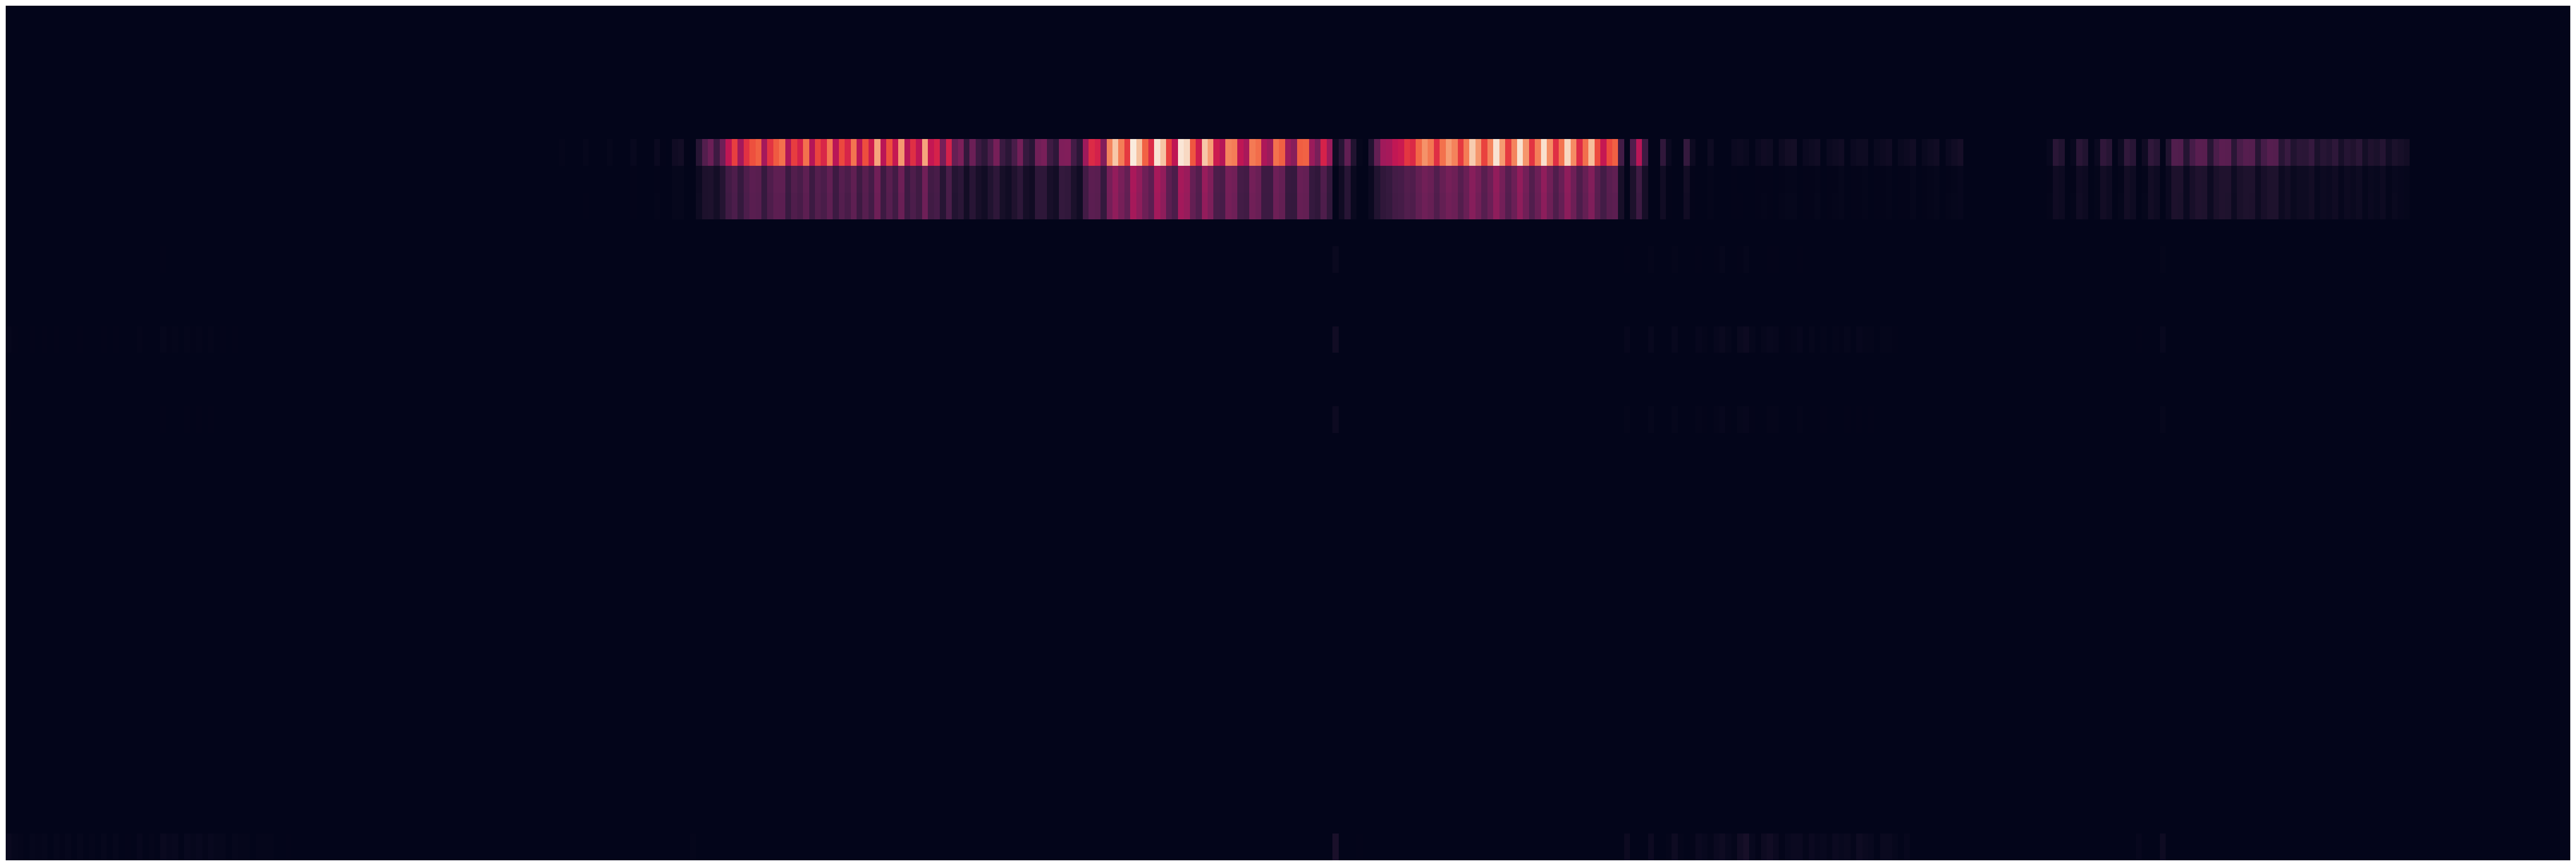

In [12]:
feat_map = features_dict[3][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=False )
plt.xticks([])  
plt.yticks([])  
plt.axis('off')  # Removes all axes ticks and spines
plt.tight_layout(pad=0)  # Minimize spacing
plt.savefig('base_feat_map.pdf')
plt.show()
plt.close()

In [22]:
from inception import Classifier_INCEPTION
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

dataset_names = ['BeetleFly']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
# columns=['Dataset', 'base_red_3',  'sparse_red_3',]

redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    input_shape = xtrain.shape[1:]
    nb_classes = len(np.unique(ytrain))
    
    model_base = Classifier_INCEPTION(input_shape, nb_classes)
    model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
     
    
    features_dict = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

    with torch.no_grad():
        for b_idx, (input, target) in enumerate(trainloader):
            input, target = input.cuda(), target.cuda()
            output, features = model_base.extract_features(input.float())
            features_dict[1].append(features[0])
            features_dict[2].append(features[1])
            features_dict[3].append(features[2])
            features_dict[4].append(features[3])
            features_dict[5].append(features[4])
            features_dict[6].append(features[5])


    features_dict[1] = torch.cat(features_dict[1], dim=0)
    features_dict[2] = torch.cat(features_dict[2], dim=0)
    features_dict[3] = torch.cat(features_dict[3], dim=0)
    features_dict[4] = torch.cat(features_dict[4], dim=0)
    features_dict[5] = torch.cat(features_dict[5], dim=0)
    features_dict[6] = torch.cat(features_dict[6], dim=0)

    
    print('\n-----------------------------------------------------------------------------------------------------------\n')
    
 


-----------------------------------------------------------------------------------------------------------



feat map shape:  torch.Size([128, 512])


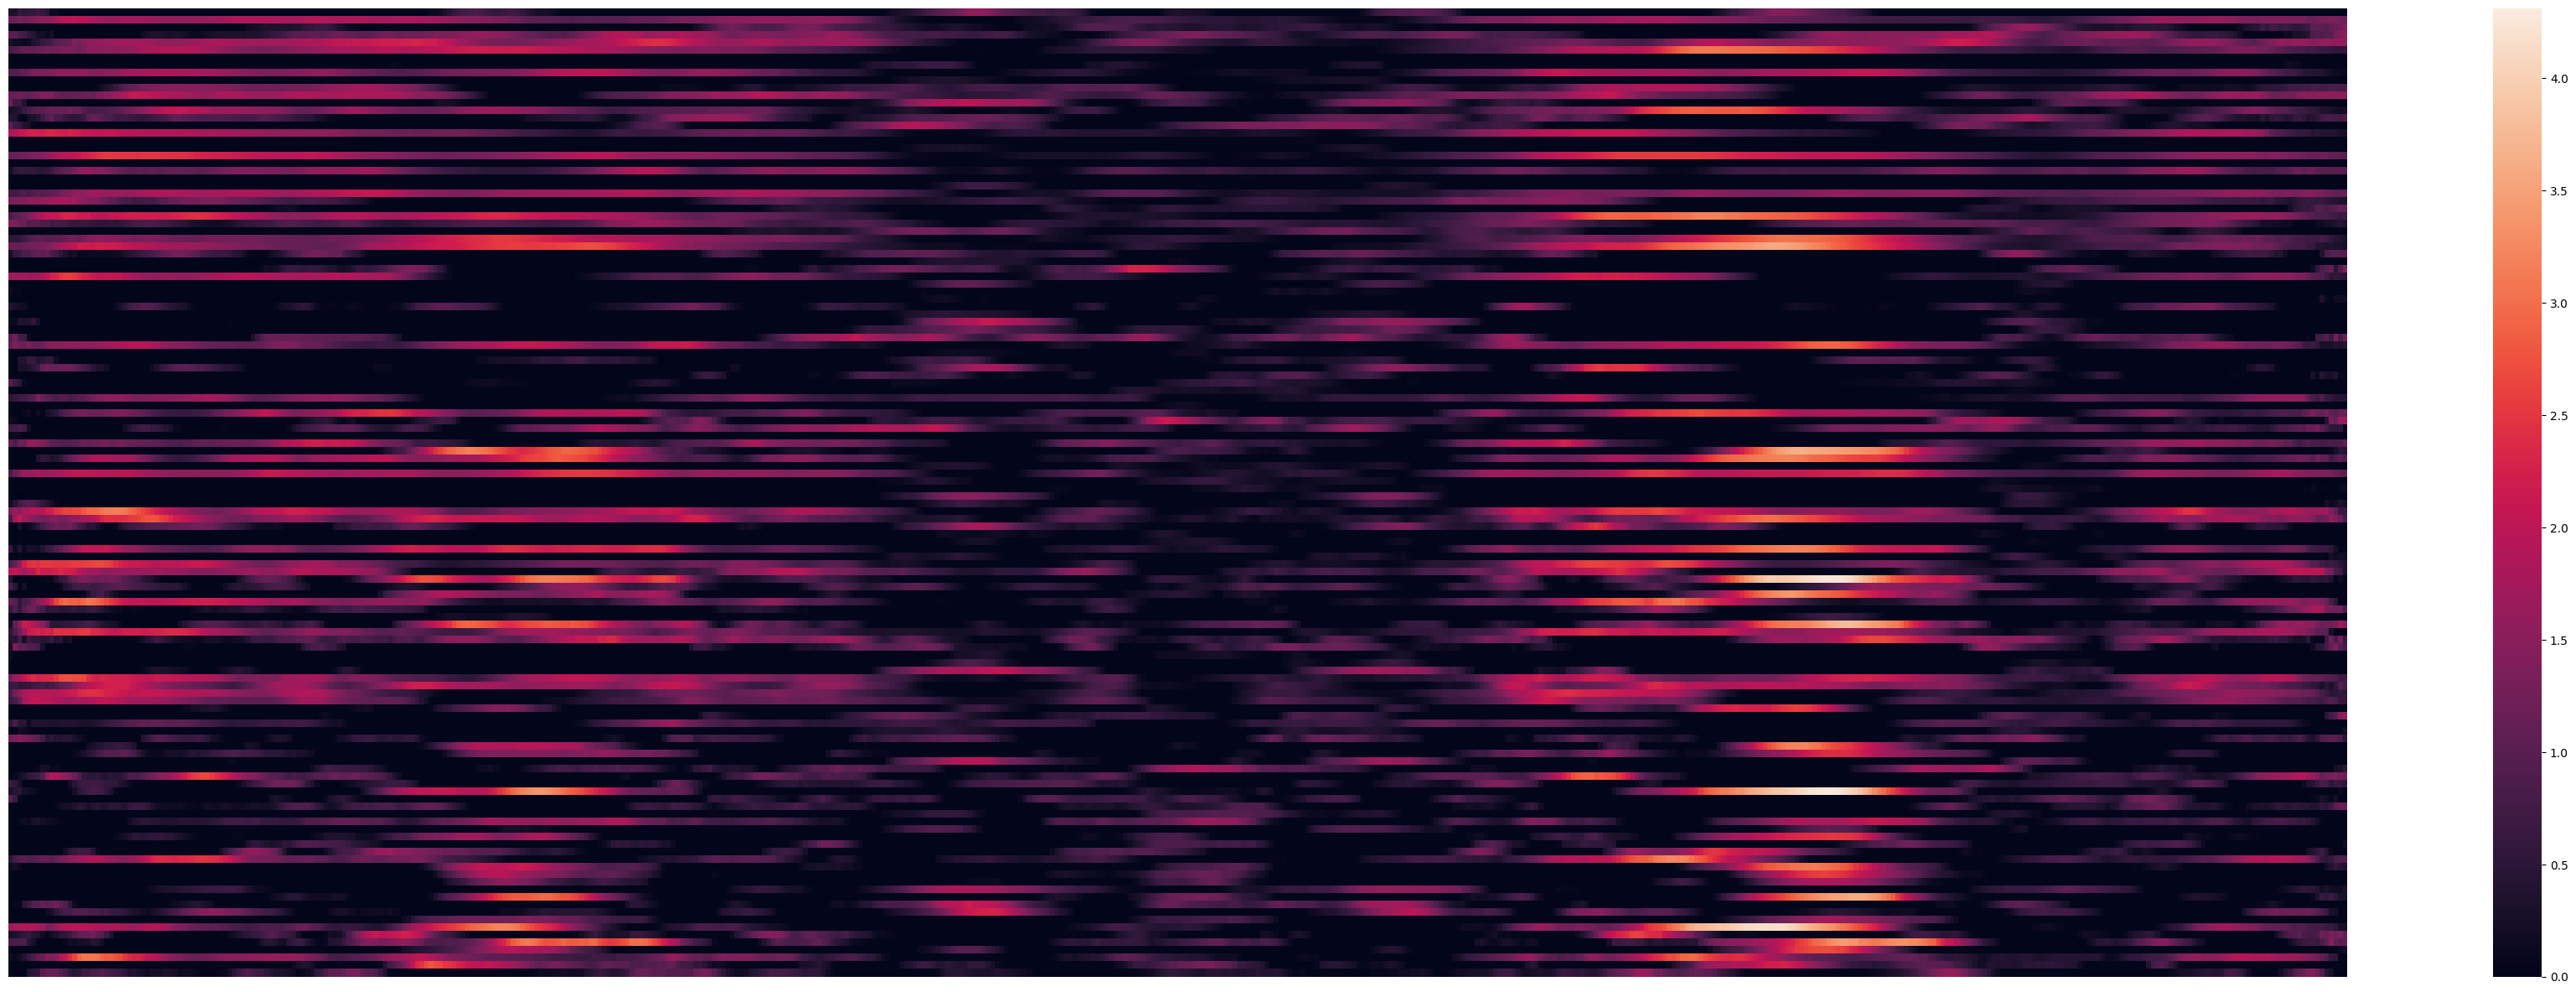

In [23]:
feat_map = features_dict[5][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

In [ ]:
from inception import Classifier_INCEPTION
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

dataset_names = ['ArrowHead']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
# columns=['Dataset', 'base_red_3',  'sparse_red_3',]

redundancy_df = pd.DataFrame(columns=columns)
seeds = [9409, 3804, 3952, 2561, 5296]
models_base = []
for dataset in dataset_names:
    for seed in seeds:
        rows = [dataset]
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
        
        input_shape = xtrain.shape[1:]
        nb_classes = len(np.unique(ytrain))

        model_base = Classifier_INCEPTION(input_shape, nb_classes)
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        
        features_dict = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

        with torch.no_grad():
            for b_idx, (input, target) in enumerate(trainloader):
                input, target = input.cuda(), target.cuda()
                output, features = model_base.extract_features(input.float())
                features_dict[1].append(features[0])
                features_dict[2].append(features[1])
                features_dict[3].append(features[2])
                features_dict[4].append(features[3])
                features_dict[5].append(features[4])
                features_dict[6].append(features[5])

        features_dict[1] = torch.cat(features_dict[1], dim=0)
        features_dict[2] = torch.cat(features_dict[2], dim=0)
        features_dict[3] = torch.cat(features_dict[3], dim=0)
        features_dict[4] = torch.cat(features_dict[4], dim=0)
        features_dict[5] = torch.cat(features_dict[5], dim=0)
        features_dict[6] = torch.cat(features_dict[6], dim=0)

        print('\n-----------------------------------------------------------------------------------------------------------\n')

In [147]:
def evaluate_ensemble_base_inception(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float()) for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            # Apply softmax to convert logits to probabilities
   
            avg_probs = sum(probs) / len(probs)

            # Get the predicted class
            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    print('')
    accuracy = accuracy_score(all_targets, all_preds)
    print(f'Ensemble Accuracy: {accuracy:.4f}')
    return accuracy

In [148]:
evaluate_ensemble_base_inception(models_base, testloader)


Ensemble Accuracy: 0.8229


0.8228571428571428

feat map shape:  torch.Size([128, 251])


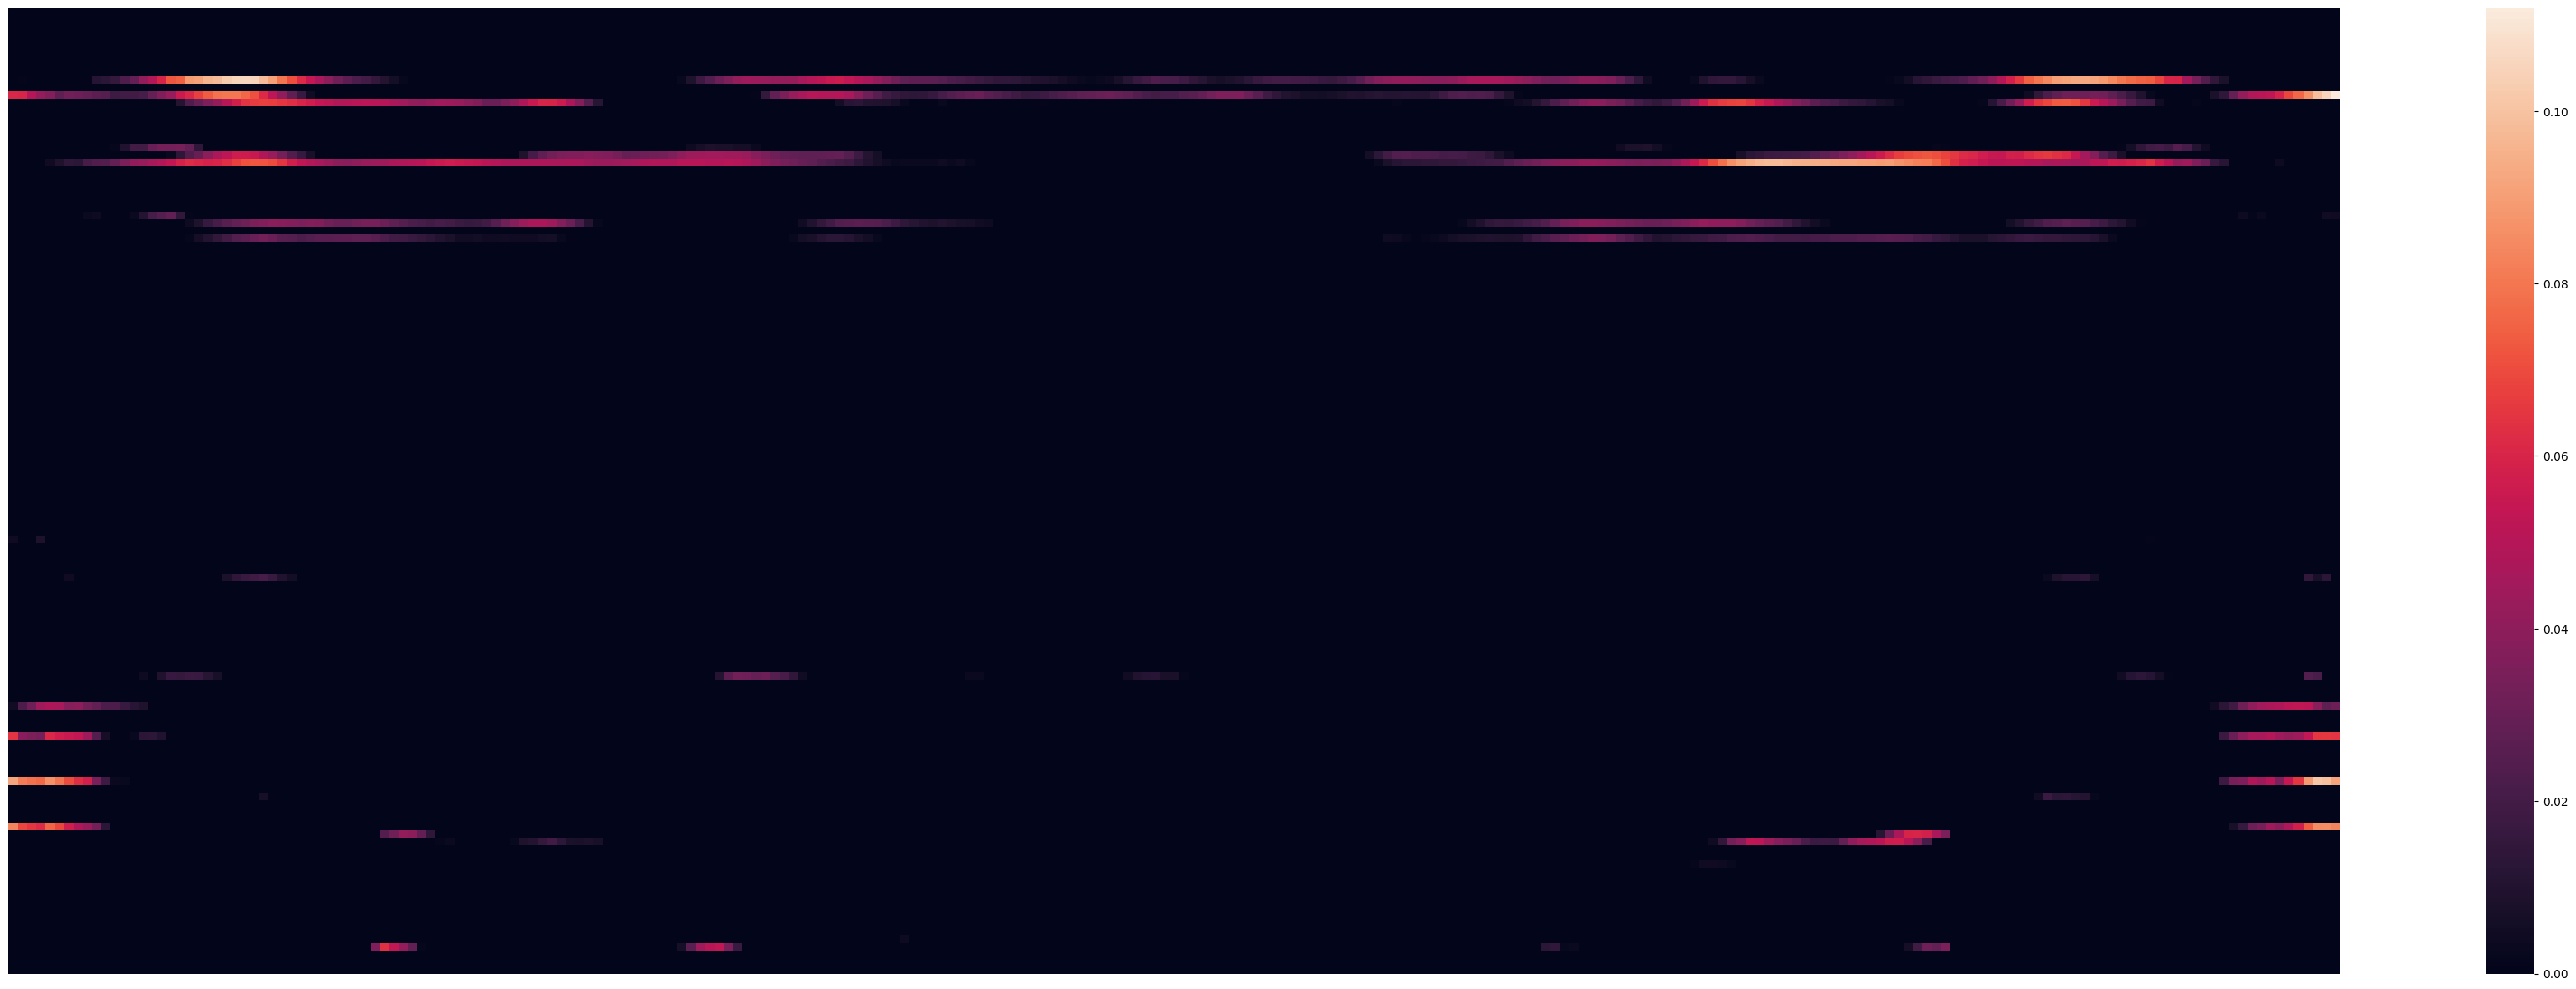

In [149]:
feat_map = features_dict[4][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

In [3]:
def test(model, valloader):
    print('From the test set evaluation')
    model.eval()
    test_loss, correct, total = 0, 0, 0

    for batch_idx, (inputs, targets) in enumerate(valloader):
        
        inputs, targets = inputs.cuda(), targets.cuda()

        outputs, _= model.forward_sparsity(inputs.float())
        loss = criterion_CE(outputs, targets)
        
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += predicted.eq(targets.data).cpu().sum().float().item()

    print('Test Loss: %.3f | Test Acc: %.3f%% (%d/%d)' % (test_loss / (batch_idx + 1), 100. * correct / total, correct, total))
    return test_loss / (batch_idx + 1), 100. * correct / total

criterion_CE = nn.CrossEntropyLoss()
import time

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# dataset_names = ['Ham']
columns=['Dataset', 'base_acc', 'pretraining_acc', 'pruning_acc',]
# columns=['Dataset', 'base_red_3',  'sparse_red_3',]

res_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    
    model_base = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    model_base.cuda()
    model_base.eval()

    start_time = time.time()
    _, acc_base = test(model_base, testloader)
    end_time = time.time()
    print('Time for inference: ', end_time - start_time)
    rows.append(acc_base)
    
    model_pretraining = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_pretraining.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
    model_pretraining.cuda()
    model_pretraining.eval()
    _, acc_pretraining = test(model_pretraining, testloader)
    rows.append(acc_pretraining)

    
    model_prune = torch.load(os.getcwd() + f'/results/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth')
    model_prune.cuda()
    model_prune.eval()

    start_time = time.time()        
    _, acc_prune = test(model_prune, testloader)
    end_time = time.time()
    print('Time for inference: ', end_time - start_time)
    
    rows.append(acc_prune)


    res_df = pd.concat([res_df, pd.DataFrame([rows], columns=columns)])


In [208]:
sum([parameter.numel() for parameter in model_base.parameters()])

10318

In [205]:
sum([parameter.numel() for parameter in model_prune.parameters()])


4002

p_value:  3.437065338184471e-14


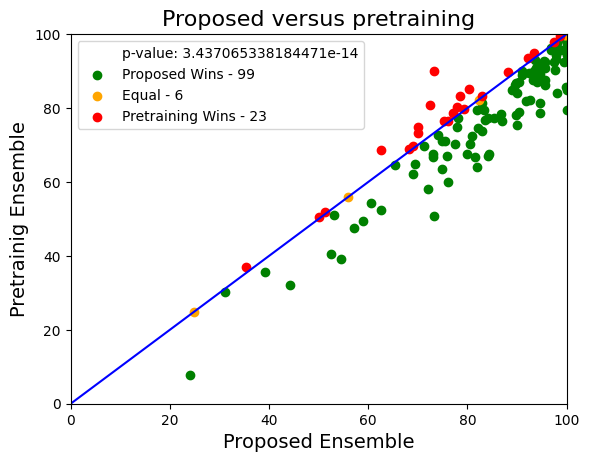

In [14]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_acc'].tolist(), res_df['pretraining_acc'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=100.01, 
              co_col='pretraining_acc', 
              base_col='base_acc', 
              xlabel='Proposed Ensemble', 
              ylabel='Pretrainig Ensemble', 
              legend_base='Proposed', 
              legend_co='Pretraining', 
              title='Proposed versus pretraining', 
              file_name='proposed_vs_pretrain')

p_value:  1.5553204835132897e-17


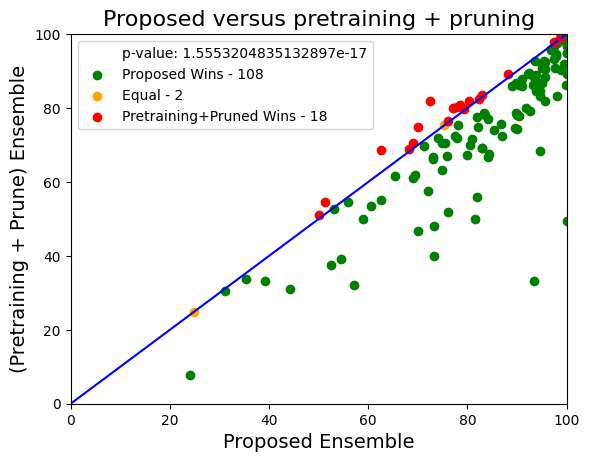

In [13]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_acc'].tolist(), res_df['pruning_acc'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=100.01, 
              co_col='pruning_acc', 
              base_col='base_acc', 
              xlabel='Proposed Ensemble', 
              ylabel='(Pretraining + Prune) Ensemble', 
              legend_base='Proposed', 
              legend_co='Pretraining+Pruned', 
              title='Proposed versus pretraining + pruning', 
              file_name='proposed_vs_pretrain+prune')